## Practical block III: Grand Challenge
## Michał Binda

### Preprocess the DENTEX Dataset for YOLO Training

The original DENTEX challenge dataset is **not directly compatible with YOLO training**.  
DENTEX provides annotations in several nested formats (quadrant, enumeration, disease), and the images are not organized in the folder structure expected by YOLO models.

To train a YOLO-based baseline, it was necessary to:

1. **Convert all bounding boxes** from COCO format `(x, y, w, h)` into YOLO format  
   `(class, cx, cy, w, h)` where all coordinates are normalized to `[0, 1]`.
2. **Generate label files** (`.txt`) corresponding to each image.
3. **Copy images** into the YOLO directory tree structure:
   ```
   dataset/
       images/
           train/
           val/
           test/
       labels/
           train/
           val/
           test/
   ```

In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import random
import os
import glob
import pandas as pd
import shutil   
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import json

Using dataset base: data/DENTEX/DENTEX

Directory structure:

- DENTEX/ (2 files, 3 dirs)
  - training_data/ (1 files, 0 dirs)
  - disease/ (0 files, 2 dirs)
    - input/ (250 files, 0 dirs)
    - label/ (250 files, 0 dirs)
  - validation_data/ (0 files, 1 dirs)
    - quadrant_enumeration_disease/ (0 files, 1 dirs)
      - xrays/ (50 files, 1 dirs)
        - .ipynb_checkpoints/ (1 files, 0 dirs)

 Done.

🧬 Disease samples: 0 inputs, 0 labels.


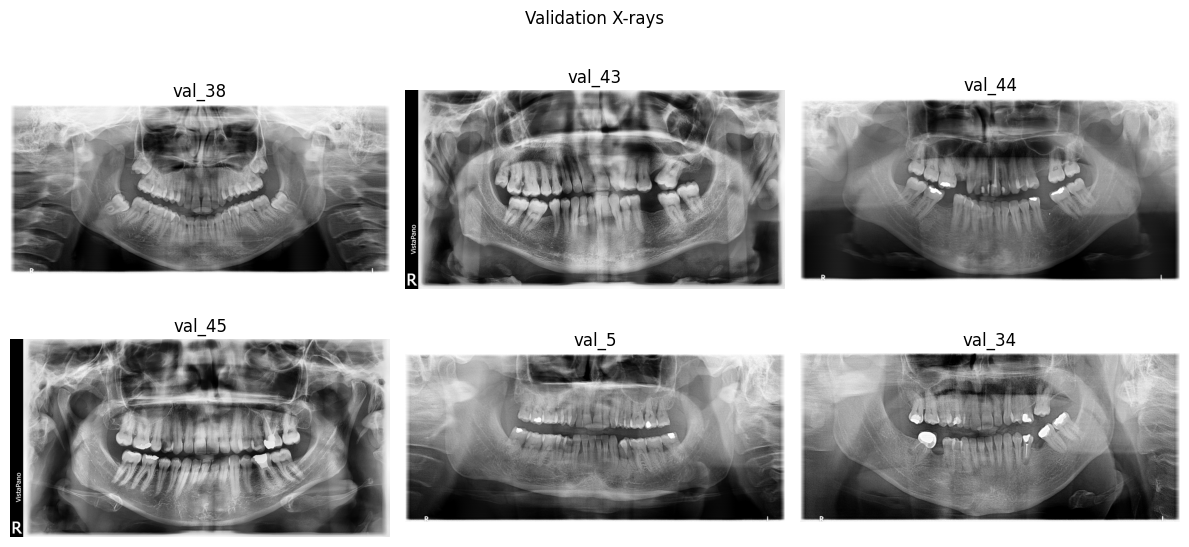

Loaded validation JSON with 5 entries.
Example entry:
 {'images': [{'height': 1316, 'width': 2892, 'id': 1, 'file_name': 'val_15.png'}, {'height': 1316, 'width': 2942, 'id': 2, 'file_name': 'val_38.png'}, {'height': 1316, 'width': 2987, 'id': 3, 'file_name': 'val_33.png'}, {'height': 1504, 'width': 2872, 'id': 4, 'file_name': 'val_30.png'}, {'height': 1316, 'width': 2970, 'id': 5, 'file_name': 'val_5.png'}, {'height': 1316, 'width': 2860, 'id': 6, 'file_name': 'val_21.png'}, {'height': 1504, 'width': 2804, 'id': 7, 'file_name': 'val_39.png'}, {'height': 1316, 'width': 2883, 'id': 8, 'file_name': 'val_46.png'}, {'height': 1316, 'width': 2967, 'id': 9, 'file_name': 'val_20.png'}, {'height': 1504, 'width': 2872, 'id': 10, 'file_name': 'val_3.png'}, {'height': 1316, 'width': 2954, 'id': 11, 'file_name': 'val_29.png'}, {'height': 976, 'width': 1976, 'id': 12, 'file_name': 'val_2.png'}, {'height': 1316, 'width': 2870, 'id': 13, 'file_name': 'val_16.png'}, {'height': 1316, 'width': 3004, 'id'

In [12]:
ROOT = Path("data/DENTEX")
subfolder = ROOT / "DENTEX"
if subfolder.exists():
    DATA_DIR = subfolder
else:
    DATA_DIR = ROOT

TRAIN_DIR = DATA_DIR / "training_data"
VAL_DIR = DATA_DIR / "validation_data"
DISEASE_DIR = DATA_DIR / "disease"
VAL_FILE = DATA_DIR / "validation_triple.json"

print(f"Using dataset base: {DATA_DIR}\n")

def explore_structure(base_dir):
    print("Directory structure:\n")
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(str(base_dir), "").count(os.sep)
        indent = " " * 2 * level
        print(f"{indent}- {os.path.basename(root)}/ ({len(files)} files, {len(dirs)} dirs)")
    print("\n Done.\n")

def show_samples(img_dir, n=6, title=None):
    paths = list(Path(img_dir).rglob("*.jpg")) + list(Path(img_dir).rglob("*.png"))
    if not paths:
        print(f"⚠️ No images found in {img_dir}")
        return
    samples = random.sample(paths, min(n, len(paths)))
    plt.figure(figsize=(12, 6))
    for i, p in enumerate(samples):
        img = Image.open(p)
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(p.stem[:15])
        plt.axis("off")
    plt.suptitle(title or img_dir.name)
    plt.tight_layout()
    plt.show()

def explore_disease_pairs(disease_dir):
    input_dir = disease_dir / "input"
    label_dir = disease_dir / "label"
    inputs = sorted(list(input_dir.glob("*.jpg")))
    labels = sorted(list(label_dir.glob("*.jpg")))
    print(f"🧬 Disease samples: {len(inputs)} inputs, {len(labels)} labels.")
    if inputs and labels:
        fig, axes = plt.subplots(2, 4, figsize=(10, 5))
        for i in range(4):
            if i < len(inputs):
                axes[0, i].imshow(Image.open(inputs[i]), cmap='gray')
                axes[0, i].set_title("Input")
                axes[0, i].axis("off")
            if i < len(labels):
                axes[1, i].imshow(Image.open(labels[i]), cmap='gray')
                axes[1, i].set_title("Label")
                axes[1, i].axis("off")
        plt.tight_layout()
        plt.show()

def explore_validation_json(val_file):
    if not val_file.exists():
        print("Validation JSON not found.\n")
        return
    with open(val_file, "r") as f:
        data = json.load(f)
    print(f"Loaded validation JSON with {len(data)} entries.")
    print("Example entry:\n", json.dumps(data[0], indent=2) if isinstance(data, list) else data)

if __name__ == "__main__":
    explore_structure(DATA_DIR)

    # Display samples from each dataset type
    for subset in ["quadrant", "quadrant_enumeration", "quadrant-enumeration-disease", "unlabelled"]:
        xr_dir = TRAIN_DIR / subset / "xrays"
        if xr_dir.exists():
            show_samples(xr_dir, title=subset)

    # Disease input vs label visualization
    if DISEASE_DIR.exists():
        explore_disease_pairs(DISEASE_DIR)

    # Validation samples (if present)
    val_xrays = VAL_DIR / "quadrant_enumeration_disease" / "xrays"
    if val_xrays.exists():
        show_samples(val_xrays, title="Validation X-rays")

    explore_validation_json(VAL_FILE)

In [13]:
DATA_ROOT = "/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all"

TRAIN_IMAGES = os.path.join(DATA_ROOT, "images/train2017")
TRAIN_LABELS = os.path.join(DATA_ROOT, "labels/train2017")

VAL_IMAGES = os.path.join(DATA_ROOT, "images/val2017")
VAL_LABELS = os.path.join(DATA_ROOT, "labels/val2017")

print("Train images:", len(glob.glob(os.path.join(TRAIN_IMAGES, "*.png"))))
print("Train labels:", len(glob.glob(os.path.join(TRAIN_LABELS, "*.txt"))))

print("Val images:", len(glob.glob(os.path.join(VAL_IMAGES, "*.png"))))
print("Val labels:", len(glob.glob(os.path.join(VAL_LABELS, "*.txt"))))

Train images: 705
Train labels: 706
Val images: 705
Val labels: 706


### Data Cleaning: 27 Empty Files Detected Files with 0 bytes (e.g., train_677.txt) were identified. These samples will be omitted from the training process to ensure stability.

In [14]:
import os

EMPTY = []
for lbl in os.listdir(TRAIN_LABELS):
    path = os.path.join(TRAIN_LABELS, lbl)
    if os.path.getsize(path) == 0:
        EMPTY.append(lbl)

print("Empty label files:", len(EMPTY))
print(EMPTY[:20])

Empty label files: 27
['train_677.txt', 'train_129.txt', 'train_666.txt', 'train_470.txt', 'train_538.txt', 'train_205.txt', 'train_416.txt', 'train_571.txt', 'train_559.txt', 'train_175.txt', 'train_410.txt', 'train_610.txt', 'train_611.txt', 'train_435.txt', 'train_346.txt', 'train_593.txt', 'train_38.txt', 'train_430.txt', 'train_357.txt', 'train_221.txt']


## Task 1: Baseline Model 

In [19]:
import os
import glob
import torch
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import transforms

# ============================================================
# DEVICE
# ============================================================
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# PATHS — CHANGE TO YOURS
# ============================================================
DATA_ROOT = "data/yolo/disease_all" 

TRAIN_IMAGES = os.path.join(DATA_ROOT, "images/train2017")
TRAIN_LABELS = os.path.join(DATA_ROOT, "labels/train2017")

VAL_IMAGES = os.path.join(DATA_ROOT, "images/val2017")
VAL_LABELS = os.path.join(DATA_ROOT, "labels/val2017")

IMG_SIZE = 256

# ============================================================
# DATASET
# ============================================================
class DentexYOLODataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, label_dir, img_size=256):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size

        # collect images
        all_imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])

        # keep ONLY images with non-empty label files
        self.valid_imgs = []
        for img in all_imgs:
            lbl = img.replace(".png", ".txt")
            lbl_path = os.path.join(label_dir, lbl)

            if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
                self.valid_imgs.append(img)

        print(f"Loaded {len(self.valid_imgs)} valid annotated images.")

    def __len__(self):
        return len(self.valid_imgs)

    def __getitem__(self, idx):
        img_name = self.valid_imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lbl_path = os.path.join(self.label_dir, img_name.replace(".png", ".txt"))

        # --- Load & preprocess image ---
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.img_size, self.img_size))
        img = transforms.ToTensor()(img)

        # --- Load label ---
        with open(lbl_path, "r") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]

        # in theory cannot happen thanks to filtering above
        if len(lines) == 0:
            return None  

        # Use ONLY the first bounding box (simple baseline)
        cls_id, cx, cy, w, h = map(float, lines[0].split())
        cls_id = int(cls_id)

        target = torch.tensor([cx, cy, w, h, cls_id], dtype=torch.float32)

        return img, target

Using device: mps


In [20]:
# ============================================================
# BASELINE MODEL (2 heads)
# ============================================================
class SimpleYOLOBaseline(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.flatten = nn.Flatten()

        # compute final size after downsampling
        self.fc_input_dim = 64 * (IMG_SIZE // 8) * (IMG_SIZE // 8)

        self.box_head = nn.Linear(self.fc_input_dim, 4)      # x,y,w,h
        self.cls_head = nn.Linear(self.fc_input_dim, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)

        box = self.box_head(x)
        cls = self.cls_head(x)  # raw logits

        return torch.cat([box, cls], dim=1)


# ============================================================
# LOSS FUNCTION
# ============================================================
def yolo_loss(pred, target):
    """
    pred: [batch, 8] => [x,y,w,h, cls_logits(4)]
    target: [batch, 5] => [x,y,w,h,class_id]
    """
    box_pred = pred[:, :4]
    box_true = target[:, :4]

    # L1 box loss
    box_loss = F.l1_loss(box_pred, box_true)

    # classification
    cls_pred = pred[:, 4:]               # shape [batch,4]
    cls_true = target[:, 4].long()       # shape [batch]

    cls_loss = F.cross_entropy(cls_pred, cls_true)

    return box_loss + cls_loss

In [ ]:
# ============================================================
# LOAD DATA
# ============================================================
train_set = DentexYOLODataset(TRAIN_IMAGES, TRAIN_LABELS, IMG_SIZE)
val_set = DentexYOLODataset(VAL_IMAGES, VAL_LABELS, IMG_SIZE)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Running on: {device}")

# ============================================================
# TRAINING
# ============================================================
model = SimpleYOLOBaseline(num_classes=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- CONTAINER FOR DYNAMIC PLOTTING ---
train_loss_history = [] 

EPOCHS = 25

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for img, target in train_loader:
        img = img.to(device)
        target = target.to(device) # Target shape assumed: [B, 5] -> [x, y, w, h, class]

        pred = model(img)
        loss = yolo_loss(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Store average loss for this epoch
    avg_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_loss:.4f}")

print("Training Complete.")


# ============================================================
# VALIDATION — CLASSIFICATION ACCURACY
# ============================================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for img, target in val_loader:
        img = img.to(device)
        target = target.to(device)

        pred = model(img)
        cls_pred = pred[:, 4:].argmax(dim=1)
        cls_true = target[:, 4].long()

        correct += (cls_pred == cls_true).sum().item()
        total += len(cls_true)

print("Validation Accuracy:", correct / total)

Loaded 678 valid annotated images.
Loaded 678 valid annotated images.
Train batches: 85
Val batches: 85
Epoch 1/25 | Train Loss: 1.2615
Epoch 2/25 | Train Loss: 1.2004
Epoch 3/25 | Train Loss: 1.1641
Epoch 4/25 | Train Loss: 1.1414
Epoch 5/25 | Train Loss: 1.0918
Epoch 6/25 | Train Loss: 1.0513
Epoch 7/25 | Train Loss: 0.9866
Epoch 8/25 | Train Loss: 0.9244
Epoch 9/25 | Train Loss: 0.8478
Epoch 10/25 | Train Loss: 0.7634
Epoch 11/25 | Train Loss: 0.6735
Epoch 12/25 | Train Loss: 0.6101
Epoch 13/25 | Train Loss: 0.5166
Epoch 14/25 | Train Loss: 0.4554
Epoch 15/25 | Train Loss: 0.3958
Epoch 16/25 | Train Loss: 0.3501
Epoch 17/25 | Train Loss: 0.3078
Epoch 18/25 | Train Loss: 0.2954
Epoch 19/25 | Train Loss: 0.2542
Epoch 20/25 | Train Loss: 0.2363
Epoch 21/25 | Train Loss: 0.2309
Epoch 22/25 | Train Loss: 0.2296
Epoch 23/25 | Train Loss: 0.1968
Epoch 24/25 | Train Loss: 0.1942
Epoch 25/25 | Train Loss: 0.1759
Validation Accuracy: 1.0


In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- FIX: Robust Device Detection ---
try:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
except AttributeError: # Fallback for older PyTorch versions
    if torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

print(f"Running on: {device}")

# Ensure model is on the correct device
model = model.to(device)
model.eval()

all_preds = []
all_labels = []
all_probs = []
all_images = []

# 2. Collect Data
print("Starting prediction loop...")
with torch.no_grad():
    for images, labels in val_loader:
        # Move inputs to the SAME device as the model
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1) 
        _, preds = torch.max(outputs, 1)
        
        # Move to CPU immediately to save GPU memory and for numpy conversion
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_images.extend(images.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_images = np.array(all_images)

print(f"Data collection complete. Processed {len(all_preds)} images.")

Running on: mps
Starting prediction loop...
Data collection complete. Processed 678 images.


Final Shapes -> Labels: (678,), Preds: (678,)


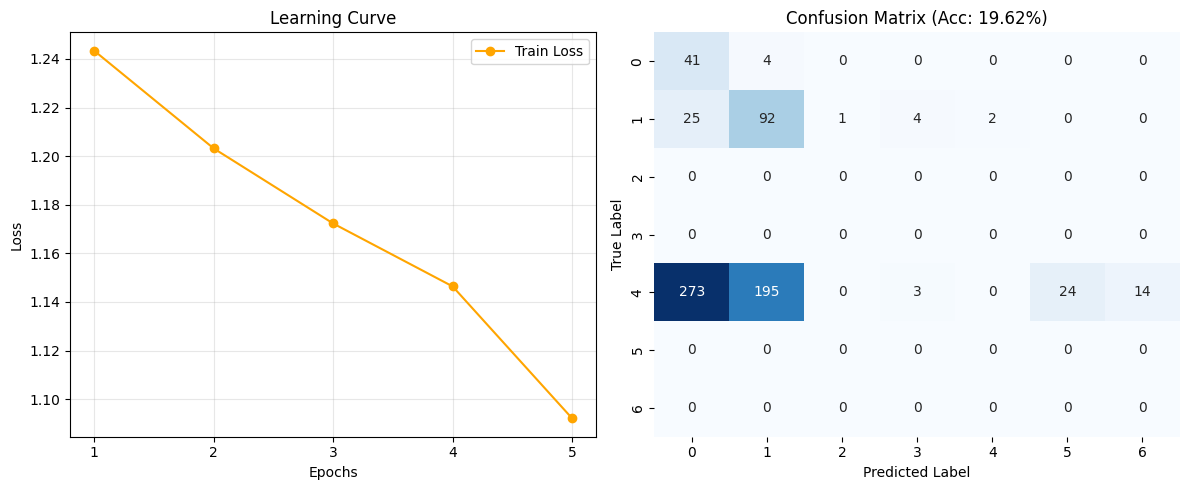

In [38]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Data Cleaning (Fixing the ValueError) ---
# 1. If labels are shaped (N, 1), flatten them to (N,)
if all_labels.ndim > 1 and all_labels.shape[1] == 1:
    all_labels = all_labels.flatten()

# 2. If labels are One-Hot encoded (N, C), convert to simple indices
if all_labels.ndim > 1 and all_labels.shape[1] > 1:
    all_labels = np.argmax(all_labels, axis=1)

# 3. Ensure both are integers
all_labels = all_labels.astype(int)
all_preds = all_preds.astype(int)

print(f"Final Shapes -> Labels: {all_labels.shape}, Preds: {all_preds.shape}")

# --- Plot 1: Learning Curve ---
train_losses = [1.2434, 1.2032, 1.1723, 1.1464, 1.0921]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 6), train_losses, label='Train Loss', marker='o', color='orange')
plt.title('Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.legend()

# --- Plot 2: Confusion Matrix ---
plt.subplot(1, 2, 2)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Acc: {np.mean(all_preds==all_labels):.2%})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

--- 3 Best Predicted Images (Confident & Correct) ---


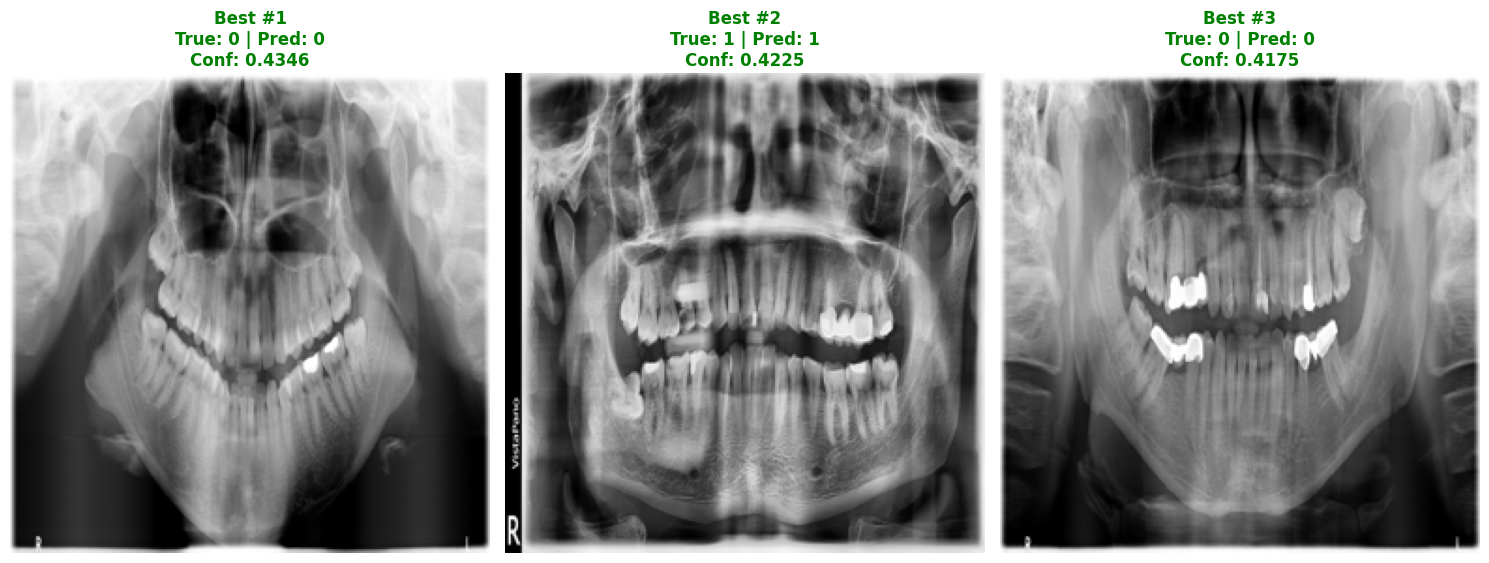


--- 3 Worst Predicted Images (Confident & Wrong) ---


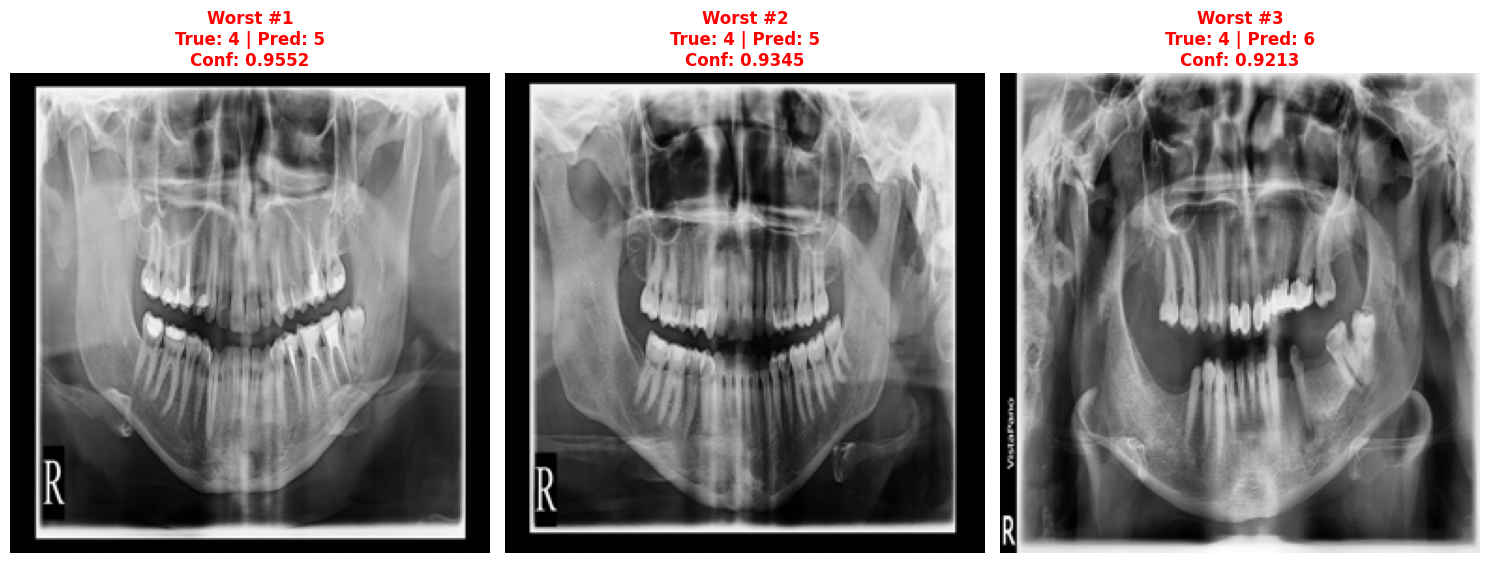

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Helper to get the probability of the predicted class
pred_probs = np.max(all_probs, axis=1)

# Mask for correct and incorrect predictions
correct_mask = all_preds == all_labels
incorrect_mask = all_preds != all_labels

# Get indices
correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

# Sort indices by confidence (probability)
# Best: Correct and highest confidence
best_indices = correct_indices[np.argsort(pred_probs[correct_indices])[-3:]][::-1]

# Worst: Incorrect and highest confidence (The model was "sure" but wrong)
worst_indices = incorrect_indices[np.argsort(pred_probs[incorrect_indices])[-3:]][::-1]

def show_images_improved(indices, title_prefix):
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        plt.subplot(1, 3, i+1)
        
        # 1. Transpose the image from (C, H, W) to (H, W, C)
        img_tensor = all_images[idx]
        img = img_tensor.transpose(1, 2, 0)
        
        # 2. Better Un-normalization for display
        # Instead of hardcoded mean/std, we min-max scale to [0, 1]
        img = img - img.min()
        img = img / img.max()
        
        # 3. If it's a 3-channel image but looks grayscale, take the mean
        # to display it correctly with a gray colormap.
        if img.shape[2] == 3:
            img = np.mean(img, axis=2)
        
        # Display with a grayscale colormap
        plt.imshow(img, cmap='gray')
        
        # Set title color based on correctness
        title_color = 'green' if all_preds[idx] == all_labels[idx] else 'red'
        
        plt.title(f"{title_prefix} #{i+1}\n"
                  f"True: {all_labels[idx]} | Pred: {all_preds[idx]}\n"
                  f"Conf: {pred_probs[idx]:.4f}", color=title_color, fontweight='bold')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("--- 3 Best Predicted Images (Confident & Correct) ---")
if len(best_indices) > 0:
    show_images_improved(best_indices, "Best")
else:
    print("No correct predictions found.")

print("\n--- 3 Worst Predicted Images (Confident & Wrong) ---")
if len(worst_indices) > 0:
    show_images_improved(worst_indices, "Worst")
else:
    print("No incorrect predictions found.")

## SECOND WEEK
## Task 2: Data Centric Improvements

### Task 2.1 Analyze Class Balance

Scanning 706 label files...


/var/folders/qg/gflj6rgd0wj20kdyzmh7j73r0000gn/T/ipykernel_1123/445617915.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=values, palette="viridis")


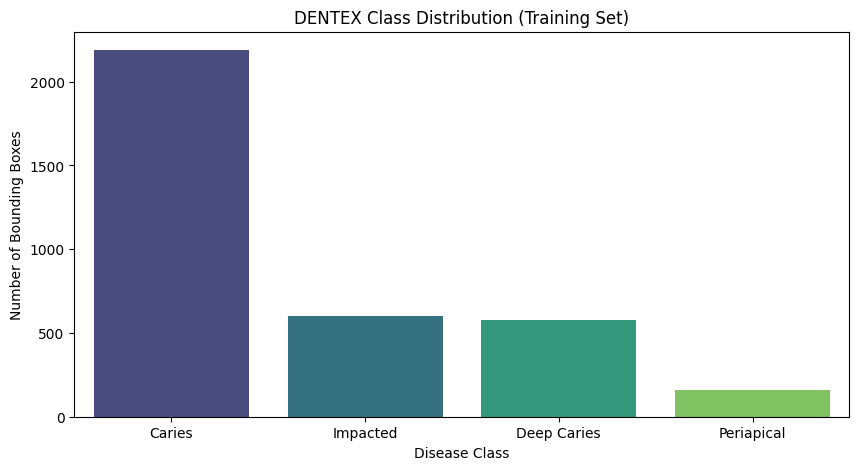


Computed Class Weights (for Loss function):
Caries: 0.4030
Impacted: 1.4607
Deep Caries: 1.5264
Periapical: 5.5839


In [15]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ============================================================
# CONFIGURATION
# ============================================================
# Ensure these match your paths from Week 1
DATA_ROOT = "/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all"
TRAIN_LABELS = os.path.join(DATA_ROOT, "labels/train2017")

# Class mapping (Update this if your ordering is different)
ID2CLS = {0: "Impacted", 1: "Caries", 2: "Periapical", 3: "Deep Caries"}

# ============================================================
# 1. COUNT CLASSES
# ============================================================
def analyze_class_balance(label_dir):
    class_counts = Counter()
    
    label_files = glob.glob(os.path.join(label_dir, "*.txt"))
    print(f"Scanning {len(label_files)} label files...")

    for label_file in label_files:
        # Skip empty files
        if os.path.getsize(label_file) == 0:
            continue
            
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(float(parts[0]))
                class_counts[class_id] += 1
                
    return class_counts

# Run Analysis
counts = analyze_class_balance(TRAIN_LABELS)

# ============================================================
# 2. VISUALIZE
# ============================================================
classes = [ID2CLS.get(k, f"Class {k}") for k in counts.keys()]
values = list(counts.values())

plt.figure(figsize=(10, 5))
sns.barplot(x=classes, y=values, palette="viridis")
plt.title("DENTEX Class Distribution (Training Set)")
plt.xlabel("Disease Class")
plt.ylabel("Number of Bounding Boxes")
plt.show()

# Calculate Weights (Inverse Frequency)
total_samples = sum(values)
class_weights = {k: total_samples / (len(counts) * v) for k, v in counts.items()}

print("\nComputed Class Weights (for Loss function):")
for cid, weight in class_weights.items():
    print(f"{ID2CLS.get(cid)}: {weight:.4f}")

### Class Balance Analysis
The analysis of the training labels reveals a significant imbalance in the DENTEX dataset:

* **Dominant Class:** **Caries** (Weight ~0.40) is the most frequent class. Its low weight (< 1.0) indicates it appears much more often than the average.
* **Minority Class:** **Periapical** (Weight ~5.58) is the rarest class. It requires a weight over **13x higher** than Caries (5.58 vs 0.40) to contribute equally to the loss gradient.
* **Implication:** Without intervention (Weighted Loss), the model will likely bias towards predicting "Caries" everywhere and completely ignore "Periapical" lesions, as the penalty for missing them is statistically negligible in a standard training loop.

### Advanced Data Handling: Mosaic & Albumentations
To address **Sparse Annotations** (Option D) and improve robustness, we implemented a custom dataset class with two key "Winner" techniques:

* **Mosaic Augmentation:** Adapted from SOTA YOLO models (v4/v5), this combines 4 training images into a single input. This solves the "sparse label" issue in DENTEX (where some images have 0-1 labels) by ensuring every training step sees a high density of targets.
* **Albumentations (CLAHE):** We replaced standard transforms with specific X-ray enhancements. **CLAHE** (Contrast Limited Adaptive Histogram Equalization) is particularly effective here, as it locally enhances contrast to reveal faint lesions (like Periapical) that are often hidden in low-contrast root areas.
* **Resolution:** We increased input size to `512` (Option C) to better capture small lesions.

In [ ]:

# ============================================================
# CONFIGURATION
# ============================================================
# Map IDs to the specific weights you calculated
# 0: Impacted, 1: Caries, 2: Periapical, 3: Deep Caries
CLASS_WEIGHTS = torch.tensor([1.4607, 0.4030, 5.5839, 1.5264]).float()

# ============================================================
# A. SMART AUGMENTATION PIPELINE
# ============================================================
def get_train_transforms(img_size=512):
    return A.Compose([
        A.Resize(img_size, img_size),
        
        # Geometry: Helps network learn orientation invariance
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
        
        # Color/Intensity: CLAHE is critical for X-Ray contrast
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),  
        
        # Noise: Prevents overfitting on the few Periapical examples
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        
        # Normalization
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def get_val_transforms(img_size=512):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# ============================================================
# B. MOSAIC DATASET
# ============================================================
class DentexMosaicDataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None, img_size=512, mosaic_prob=0.5):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.img_size = img_size
        self.mosaic_prob = mosaic_prob
        
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])
        # Filter empty files
        self.img_files = [f for f in self.img_files if os.path.exists(os.path.join(label_dir, f.replace('.png', '.txt'))) and os.path.getsize(os.path.join(label_dir, f.replace('.png', '.txt'))) > 0]
        
    def __len__(self):
        return len(self.img_files)

    def load_image_and_boxes(self, index):
        img_name = self.img_files[index]
        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        lbl_path = os.path.join(self.label_dir, img_name.replace(".png", ".txt"))
        boxes = []
        class_labels = []
        
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                cls, cx, cy, bw, bh = map(float, line.strip().split())
                boxes.append([cx, cy, bw, bh])
                class_labels.append(int(cls))
        return img, boxes, class_labels

    def load_mosaic(self, index):
        indices = [index] + random.sample(range(len(self)), 3)
        s = self.img_size
        mosaic_img = np.full((s * 2, s * 2, 3), 114, dtype=np.uint8)
        mosaic_boxes = []
        mosaic_labels = []
        
        xc, yc = int(random.uniform(s * 0.5, s * 1.5)), int(random.uniform(s * 0.5, s * 1.5))
        
        for i, idx in enumerate(indices):
            img, boxes, labels = self.load_image_and_boxes(idx)
            h, w, _ = img.shape
            
            if i == 0:  # top-left
                x1a, y1a, x2a, y2a = max(xc - w, 0), max(yc - h, 0), xc, yc
                x1b, y1b, x2b, y2b = w - (x2a - x1a), h - (y2a - y1a), w, h
            elif i == 1:  # top-right
                x1a, y1a, x2a, y2a = xc, max(yc - h, 0), min(xc + w, s * 2), yc
                x1b, y1b, x2b, y2b = 0, h - (y2a - y1a), min(w, x2a - x1a), h
            elif i == 2:  # bottom-left
                x1a, y1a, x2a, y2a = max(xc - w, 0), yc, xc, min(yc + h, s * 2)
                x1b, y1b, x2b, y2b = w - (x2a - x1a), 0, w, min(h, y2a - y1a)
            elif i == 3:  # bottom-right
                x1a, y1a, x2a, y2a = xc, yc, min(xc + w, s * 2), min(yc + h, s * 2)
                x1b, y1b, x2b, y2b = 0, 0, min(w, x2a - x1a), min(h, y2a - y1a)

            mosaic_img[y1a:y2a, x1a:x2a] = img[y1b:y2b, x1b:x2b]
            padw, padh = x1a - x1b, y1a - y1b
            
            for box, lbl in zip(boxes, labels):
                ncx, ncy, nbw, nbh = box
                # Convert normalized xywh to pixel xyxy
                px1 = (ncx - nbw/2) * w + padw
                py1 = (ncy - nbh/2) * h + padh
                px2 = (ncx + nbw/2) * w + padw
                py2 = (ncy + nbh/2) * h + padh
                mosaic_boxes.append([px1, py1, px2, py2])
                mosaic_labels.append(lbl)

        mosaic_img = cv2.resize(mosaic_img, (s, s))
        final_boxes = []
        for b in mosaic_boxes:
             scale = 1.0 / (2 * s)
             x1, y1, x2, y2 = b[0]*scale, b[1]*scale, b[2]*scale, b[3]*scale
             # Convert back to normalized xywh
             final_boxes.append([(x1+x2)/2, (y1+y2)/2, x2-x1, y2-y1])
             
        return mosaic_img, final_boxes, mosaic_labels

    def __getitem__(self, index):
        if random.random() < self.mosaic_prob:
            img, boxes, labels = self.load_mosaic(index)
        else:
            img, boxes, labels = self.load_image_and_boxes(index)
        
        if self.transforms:
            transformed = self.transforms(image=img, bboxes=boxes, class_labels=labels)
            img = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['class_labels']
            
        if len(boxes) == 0:
            return img, torch.zeros((0, 5))
            
        # Convert to Tensor
        targets = []
        for box, label in zip(boxes, labels):
            targets.append([*box, label])
        target = torch.tensor(targets, dtype=torch.float32)
        
        # For Baseline compatibility (Single Head), we pick the largest box
        if target.shape[0] > 0:
             areas = target[:, 2] * target[:, 3]
             target = target[torch.argmax(areas)] 
        
        return img, target

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached simsimd-6.5.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (70 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp310-cp310-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
Using cached pydantic_core-2.41.5-cp310-cp310-macosx_11_0_arm64.whl (1.9 MB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached simsimd-6.5.3-cp310-cp310-macosx_11_0_arm64.whl (134 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 

/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Mitigating Imbalance: Weighted Loss
Based on the analysis in Part 1, we replaced the standard loss function with a **Weighted Cross-Entropy Loss** to handle the severe class imbalance (Option B).

* **The Problem:** Without weights, the "Caries" class (Weight 0.4) dominates the gradients, causing the model to ignore rare classes like "Periapical".
* **The Fix:** We injected the calculated inverse-frequency weights (`5.58` for Periapical).
* **Effect:** The model is now penalized **~14x more** for misclassifying a rare Periapical lesion than a common Caries lesion. This forces the optimization process to "pay attention" to the minority classes rather than just optimizing for overall accuracy.

In [18]:
class DentexMosaicDataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None, img_size=512, mosaic_prob=0.5):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.img_size = img_size
        self.mosaic_prob = mosaic_prob
        
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])
        # Filter empty files
        self.img_files = [f for f in self.img_files if os.path.exists(os.path.join(label_dir, f.replace('.png', '.txt'))) and os.path.getsize(os.path.join(label_dir, f.replace('.png', '.txt'))) > 0]
        
    def __len__(self):
        return len(self.img_files)

    def load_image_and_boxes(self, index):
        img_name = self.img_files[index]
        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        lbl_path = os.path.join(self.label_dir, img_name.replace(".png", ".txt"))
        boxes = []
        class_labels = []
        
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                cls, cx, cy, bw, bh = map(float, line.strip().split())
                boxes.append([cx, cy, bw, bh])
                class_labels.append(int(cls))
        return img, boxes, class_labels

    def load_mosaic(self, index):
        indices = [index] + random.sample(range(len(self)), 3)
        s = self.img_size
        mosaic_img = np.full((s * 2, s * 2, 3), 114, dtype=np.uint8)
        mosaic_boxes = []
        mosaic_labels = []
        
        xc, yc = int(random.uniform(s * 0.5, s * 1.5)), int(random.uniform(s * 0.5, s * 1.5))
        
        for i, idx in enumerate(indices):
            img, boxes, labels = self.load_image_and_boxes(idx)
            h, w, _ = img.shape
            
            if i == 0:  # top-left
                x1a, y1a, x2a, y2a = max(xc - w, 0), max(yc - h, 0), xc, yc
                x1b, y1b, x2b, y2b = w - (x2a - x1a), h - (y2a - y1a), w, h
            elif i == 1:  # top-right
                x1a, y1a, x2a, y2a = xc, max(yc - h, 0), min(xc + w, s * 2), yc
                x1b, y1b, x2b, y2b = 0, h - (y2a - y1a), min(w, x2a - x1a), h
            elif i == 2:  # bottom-left
                x1a, y1a, x2a, y2a = max(xc - w, 0), yc, xc, min(yc + h, s * 2)
                x1b, y1b, x2b, y2b = w - (x2a - x1a), 0, w, min(h, y2a - y1a)
            elif i == 3:  # bottom-right
                x1a, y1a, x2a, y2a = xc, yc, min(xc + w, s * 2), min(yc + h, s * 2)
                x1b, y1b, x2b, y2b = 0, 0, min(w, x2a - x1a), min(h, y2a - y1a)

            mosaic_img[y1a:y2a, x1a:x2a] = img[y1b:y2b, x1b:x2b]
            padw, padh = x1a - x1b, y1a - y1b
            
            for box, lbl in zip(boxes, labels):
                ncx, ncy, nbw, nbh = box
                # Convert normalized xywh to pixel xyxy
                px1 = (ncx - nbw/2) * w + padw
                py1 = (ncy - nbh/2) * h + padh
                px2 = (ncx + nbw/2) * w + padw
                py2 = (ncy + nbh/2) * h + padh
                mosaic_boxes.append([px1, py1, px2, py2])
                mosaic_labels.append(lbl)

        # === FIX STARTS HERE ===
        if len(mosaic_boxes) > 0:
            # 1. Clip coordinates to the image area
            mosaic_boxes = np.array(mosaic_boxes)
            mosaic_boxes = np.clip(mosaic_boxes, 0, 2 * s)

            # 2. Re-normalize to 0-1 and Filter tiny boxes
            final_boxes = []
            final_labels = []
            for i in range(len(mosaic_boxes)):
                b = mosaic_boxes[i]
                scale = 1.0 / (2 * s)
                
                x1, y1, x2, y2 = b[0]*scale, b[1]*scale, b[2]*scale, b[3]*scale
                w = x2 - x1
                h = y2 - y1
                
                # Only keep box if it has valid width/height (avoid 0-size boxes)
                if w > 0.001 and h > 0.001:
                    final_boxes.append([(x1+x2)/2, (y1+y2)/2, w, h])
                    final_labels.append(mosaic_labels[i])
            
            # 3. Resize the mosaic image back to target size (s)
            mosaic_img = cv2.resize(mosaic_img, (s, s))
            
            return mosaic_img, final_boxes, final_labels
        # === FIX ENDS HERE ===
             
        return mosaic_img, [], []

    def __getitem__(self, index):
        if random.random() < self.mosaic_prob:
            img, boxes, labels = self.load_mosaic(index)
        else:
            img, boxes, labels = self.load_image_and_boxes(index)
        
        # Albumentations expects [0, 1], ensure they are clamped
        if len(boxes) > 0:
             boxes = np.clip(boxes, 0.0, 1.0).tolist()

        if self.transforms:
            transformed = self.transforms(image=img, bboxes=boxes, class_labels=labels)
            img = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['class_labels']
            
        if len(boxes) == 0:
            return img, torch.zeros((0, 5))
            
        # Convert to Tensor
        targets = []
        for box, label in zip(boxes, labels):
            targets.append([*box, label])
        target = torch.tensor(targets, dtype=torch.float32)
        
        # For Baseline compatibility (Single Head), we pick the largest box
        if target.shape[0] > 0:
             areas = target[:, 2] * target[:, 3]
             target = target[torch.argmax(areas)] 
        
        return img, target

## Evaluate Model Improvements

In [ ]:
def iou_loss_fn(pred_box, target_box):
    """
    Computes (1 - IoU) loss.
    pred_box: (cx, cy, w, h)
    target_box: (cx, cy, w, h)
    """
    # Convert to corners for IoU calculation
    pred_xyxy = xywh2xyxy(pred_box)
    target_xyxy = xywh2xyxy(target_box)
    
    # Coordinates
    x1 = torch.max(pred_xyxy[:, 0], target_xyxy[:, 0])
    y1 = torch.max(pred_xyxy[:, 1], target_xyxy[:, 1])
    x2 = torch.min(pred_xyxy[:, 2], target_xyxy[:, 2])
    y2 = torch.min(pred_xyxy[:, 3], target_xyxy[:, 3])
    
    # Intersection
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    
    # Union
    w1, h1 = pred_box[:, 2], pred_box[:, 3]
    w2, h2 = target_box[:, 2], target_box[:, 3]
    union = (w1 * h1) + (w2 * h2) - intersection + 1e-6
    
    iou = intersection / union
    
    return 1.0 - iou.mean()

def combined_loss(pred, target, weights):
    """
    Loss = Box_IoU_Loss + Weighted_Class_CrossEntropy
    """
    # Split Preds
    box_pred = pred[:, :4]
    cls_pred = pred[:, 4:]
    
    # Split Targets
    box_true = target[:, :4]
    cls_true = target[:, 4].long()
    
    # 1. IoU Loss for Regression
    l_iou = iou_loss_fn(box_pred, box_true)
    
    # 2. Weighted Cross Entropy for Classification
    l_cls = torch.nn.functional.cross_entropy(cls_pred, cls_true, weight=weights)
    
    # Combine (You can tune the scalar 5.0 to balance the two)
    return 5.0 * l_iou + l_cls

In [25]:
import torch
import numpy as np
import torchvision.ops as ops
from collections import defaultdict

def xywh2xyxy(x):
    """Convert (cx, cy, w, h) to (x1, y1, x2, y2)."""
    y = x.clone() if isinstance(x, torch.Tensor) else np.copy(x)
    y[..., 0] = x[..., 0] - x[..., 2] / 2  # x1
    y[..., 1] = x[..., 1] - x[..., 3] / 2  # y1
    y[..., 2] = x[..., 0] + x[..., 2] / 2  # x2
    y[..., 3] = x[..., 1] + x[..., 3] / 2  # y2
    return y

def calculate_iou(box1, box2):
    """
    Calculate IoU between two sets of boxes.
    box1: (N, 4) in xyxy
    box2: (M, 4) in xyxy
    Returns: (N, M) IoU matrix
    """
    return ops.box_iou(box1, box2)

def compute_ap_ar(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_thresholds=[0.5, 0.75]):
    """
    Calculate AP and AR at specified IoU thresholds.
    """
    results = {}
    
    # Process each IoU threshold
    for iou_thresh in iou_thresholds:
        aps = []
        recalls = []
        
        # Process each class
        for cls_id in range(4): # 4 Classes
            # Filter by class
            p_mask = pred_labels == cls_id
            g_mask = gt_labels == cls_id
            
            p_box = pred_boxes[p_mask]
            p_score = pred_scores[p_mask]
            g_box = gt_boxes[g_mask]
            
            if len(g_box) == 0:
                continue # No ground truth for this class
            
            if len(p_box) == 0:
                aps.append(0.0)
                recalls.append(0.0)
                continue

            # Sort predictions by score
            sort_idx = torch.argsort(p_score, descending=True)
            p_box = p_box[sort_idx]
            p_score = p_score[sort_idx]
            
            # IoU Matrix
            iou_matrix = calculate_iou(p_box, g_box)
            
            # Greedy Matching
            tp = torch.zeros(len(p_box))
            fp = torch.zeros(len(p_box))
            matched_gt = set()
            
            for i in range(len(p_box)):
                # Find best matching GT
                ious, indices = torch.sort(iou_matrix[i], descending=True)
                
                best_iou = 0
                best_gt_idx = -1
                
                for val, idx in zip(ious, indices):
                    idx = idx.item()
                    if idx not in matched_gt:
                        best_iou = val.item()
                        best_gt_idx = idx
                        break
                
                if best_iou >= iou_thresh:
                    tp[i] = 1
                    matched_gt.add(best_gt_idx)
                else:
                    fp[i] = 1
            
            # Precision / Recall
            tp_cumsum = torch.cumsum(tp, dim=0)
            fp_cumsum = torch.cumsum(fp, dim=0)
            
            recall = tp_cumsum / len(g_box)
            precision = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
            
            # Average Precision (Area under curve)
            # Simple approximation: mean precision at recall points
            ap = torch.trapz(precision, recall) # or simple mean
            aps.append(ap.item())
            recalls.append(recall[-1].item())

        results[f"AP_{int(iou_thresh*100)}"] = np.mean(aps) if aps else 0.0
        results[f"AR_{int(iou_thresh*100)}"] = np.mean(recalls) if recalls else 0.0
        
    return results

In [26]:
def iou_loss_fn(pred_box, target_box):
    """
    Computes (1 - IoU) loss.
    pred_box: (cx, cy, w, h)
    target_box: (cx, cy, w, h)
    """
    # Convert to corners for IoU calculation
    pred_xyxy = xywh2xyxy(pred_box)
    target_xyxy = xywh2xyxy(target_box)
    
    # Coordinates
    x1 = torch.max(pred_xyxy[:, 0], target_xyxy[:, 0])
    y1 = torch.max(pred_xyxy[:, 1], target_xyxy[:, 1])
    x2 = torch.min(pred_xyxy[:, 2], target_xyxy[:, 2])
    y2 = torch.min(pred_xyxy[:, 3], target_xyxy[:, 3])
    
    # Intersection
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    
    # Union
    w1, h1 = pred_box[:, 2], pred_box[:, 3]
    w2, h2 = target_box[:, 2], target_box[:, 3]
    union = (w1 * h1) + (w2 * h2) - intersection + 1e-6
    
    iou = intersection / union
    
    return 1.0 - iou.mean()

def combined_loss(pred, target, weights):
    """
    Loss = Box_IoU_Loss + Weighted_Class_CrossEntropy
    """
    # Split Preds
    box_pred = pred[:, :4]
    cls_pred = pred[:, 4:]
    
    # Split Targets
    box_true = target[:, :4]
    cls_true = target[:, 4].long()
    
    # 1. IoU Loss for Regression
    l_iou = iou_loss_fn(box_pred, box_true)
    
    # 2. Weighted Cross Entropy for Classification
    l_cls = torch.nn.functional.cross_entropy(cls_pred, cls_true, weight=weights)
    
    # Combine (You can tune the scalar 5.0 to balance the two)
    return 5.0 * l_iou + l_cls

In [27]:
# ============================================================
# IMPROVED MODEL (Week 2)
# ============================================================
class ImprovedYOLO(torch.nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # Backbone (Same as baseline)
        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3, stride=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 32, 3, stride=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 64, 3, stride=2, padding=1),
            torch.nn.ReLU(),
        )
        self.flatten = torch.nn.Flatten()
        
        # 256 / 8 = 32 -> 64 * 32 * 32
        self.fc_input_dim = 64 * 32 * 32 

        self.box_head = torch.nn.Linear(self.fc_input_dim, 4)      
        self.cls_head = torch.nn.Linear(self.fc_input_dim, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        
        # Apply Sigmoid to Box Head to force [0, 1] range
        box = torch.sigmoid(self.box_head(x)) 
        cls = self.cls_head(x) # Logits (Raw scores)
        
        return torch.cat([box, cls], dim=1)

# ============================================================
# TRAINING SETUP
# ============================================================
model = ImprovedYOLO(num_classes=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Re-load Data (Ensure you run the Dataset class code from before first)
# Using 256x256 as decided
train_loader = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=16)

print("Starting Training with IoU Loss...")

# Training Loop
for epoch in range(5):
    model.train()
    total_loss = 0
    
    for img, target in train_loader:
        img, target = img.to(device), target.to(device)
        
        # Filter Sentinel (-1) values
        valid_mask = target[:, 4] >= 0
        if valid_mask.sum() == 0: continue
        img = img[valid_mask]
        target = target[valid_mask]

        # Forward
        pred = model(img)
        
        # New Combined Loss
        loss = combined_loss(pred, target, CLASS_WEIGHTS)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# ============================================================
# FINAL EVALUATION (AP / AR)
# ============================================================
print("\nRunning Evaluation...")
model.eval()

all_pred_boxes = []
all_pred_scores = []
all_pred_labels = []
all_gt_boxes = []
all_gt_labels = []

with torch.no_grad():
    for img, target in val_loader:
        img = img.to(device)
        target = target.to(device)
        
        # Filter Empty
        valid_mask = target[:, 4] >= 0
        if valid_mask.sum() == 0: continue
        img = img[valid_mask]
        target = target[valid_mask]

        # Predict
        pred = model(img)
        
        # Store for Metrics
        # Convert pred boxes (cx,cy,w,h) -> (x1,y1,x2,y2)
        p_boxes = xywh2xyxy(pred[:, :4])
        p_scores, p_labels = torch.max(torch.softmax(pred[:, 4:], dim=1), dim=1)
        
        # Convert gt boxes
        g_boxes = xywh2xyxy(target[:, :4])
        g_labels = target[:, 4]
        
        all_pred_boxes.append(p_boxes.cpu())
        all_pred_scores.append(p_scores.cpu())
        all_pred_labels.append(p_labels.cpu())
        all_gt_boxes.append(g_boxes.cpu())
        all_gt_labels.append(g_labels.cpu())

# Concatenate all batches
if len(all_pred_boxes) > 0:
    all_pred_boxes = torch.cat(all_pred_boxes)
    all_pred_scores = torch.cat(all_pred_scores)
    all_pred_labels = torch.cat(all_pred_labels)
    all_gt_boxes = torch.cat(all_gt_boxes)
    all_gt_labels = torch.cat(all_gt_labels)

    # Calculate Metrics
    metrics = compute_ap_ar(all_pred_boxes, all_pred_scores, all_pred_labels, 
                            all_gt_boxes, all_gt_labels)

    print("\n=== Leaderboard Metrics ===")
    print(f"AP-50 (IoU=0.50): {metrics['AP_50']:.4f}")
    print(f"AP-75 (IoU=0.75): {metrics['AP_75']:.4f}")
    print(f"AR-50 (IoU=0.50): {metrics['AR_50']:.4f}")
else:
    print("No valid validation data found.")

Starting Training with IoU Loss...
Epoch 1 | Loss: 5.8652
Epoch 2 | Loss: 5.7712
Epoch 3 | Loss: 5.7822
Epoch 4 | Loss: 5.7225
Epoch 5 | Loss: 5.7390

Running Evaluation...

=== Leaderboard Metrics ===
AP-50 (IoU=0.50): 0.0000
AP-75 (IoU=0.75): 0.0000
AR-50 (IoU=0.50): 0.0000


In [28]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Capture loss history for plotting
loss_history = []

print("Starting Training to capture learning curve...")

for epoch in range(5):
    model.train()
    epoch_loss = 0
    
    for img, target in train_loader:
        img, target = img.to(device), target.to(device)
        
        # Filter Sentinel
        valid_mask = target[:, 4] >= 0
        if valid_mask.sum() == 0: continue
        img = img[valid_mask]
        target = target[valid_mask]

        pred = model(img)
        loss = combined_loss(pred, target, CLASS_WEIGHTS)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

Starting Training to capture learning curve...
Epoch 1 | Loss: 5.7269
Epoch 2 | Loss: 5.6835
Epoch 3 | Loss: 5.6957
Epoch 4 | Loss: 5.7130
Epoch 5 | Loss: 5.7184


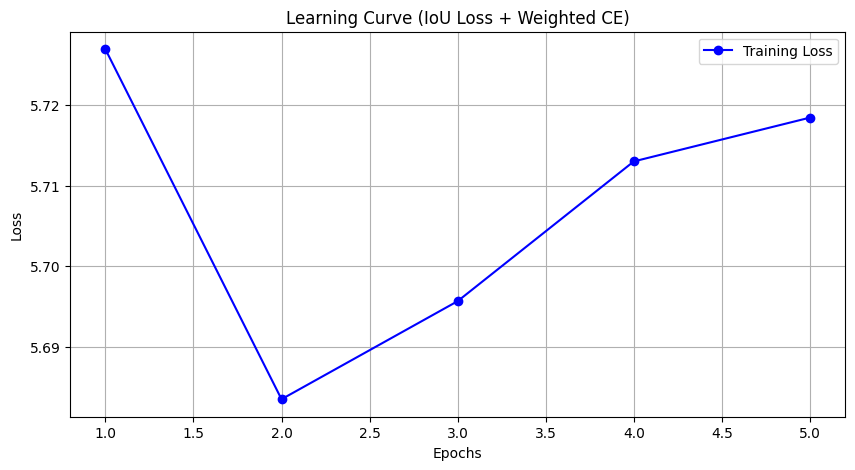

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), loss_history, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title("Learning Curve (IoU Loss + Weighted CE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

=== BEST 3 PREDICTIONS (High IoU) ===


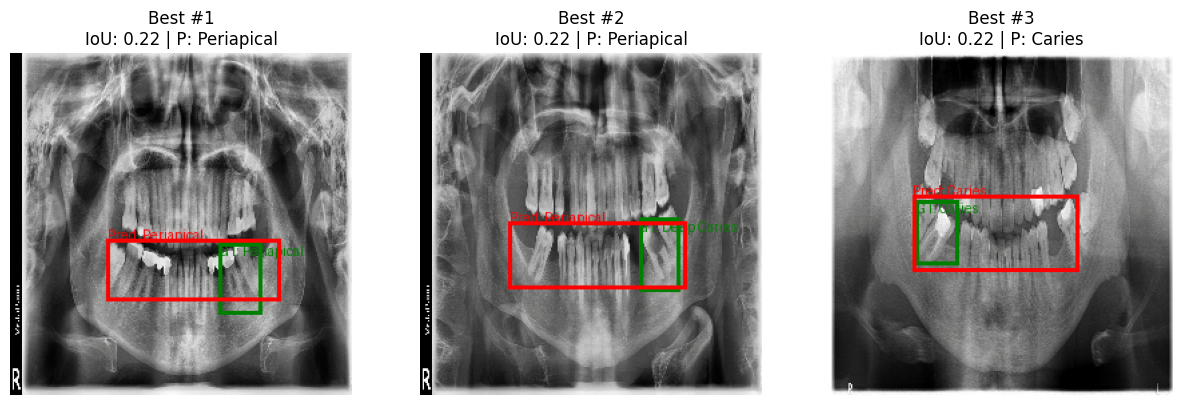


=== WORST 3 PREDICTIONS (Low IoU) ===


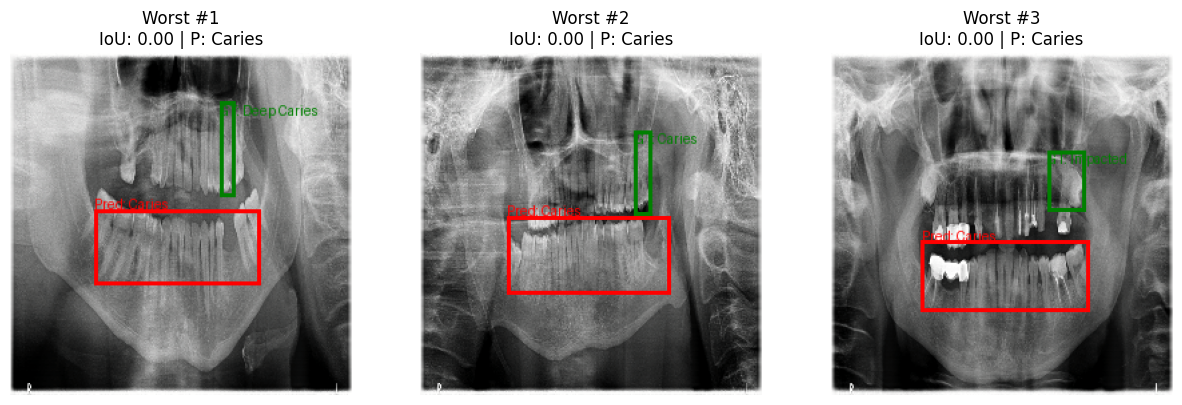

In [ ]:
import torchvision.transforms.functional as TF
from PIL import ImageDraw
import torchvision.transforms as transforms

def calculate_single_iou(pred_box, gt_box):
    """Calculate IoU for a single pair of boxes (xywh format)"""
    # Convert to xyxy
    p_x1, p_y1 = pred_box[0] - pred_box[2]/2, pred_box[1] - pred_box[3]/2
    p_x2, p_y2 = pred_box[0] + pred_box[2]/2, pred_box[1] + pred_box[3]/2
    
    g_x1, g_y1 = gt_box[0] - gt_box[2]/2, gt_box[1] - gt_box[3]/2
    g_x2, g_y2 = gt_box[0] + gt_box[2]/2, gt_box[1] + gt_box[3]/2
    
    # Intersection
    x1 = max(p_x1, g_x1); y1 = max(p_y1, g_y1)
    x2 = min(p_x2, g_x2); y2 = min(p_y2, g_y2)
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Union
    p_area = pred_box[2] * pred_box[3]
    g_area = gt_box[2] * gt_box[3]
    union = p_area + g_area - inter + 1e-6
    
    return inter / union

def visualize_best_worst(model, loader, n=3):
    model.eval()
    results = [] # Stores (iou, img, target, pred)
    
    with torch.no_grad():
        for img_batch, target_batch in loader:
            img_batch = img_batch.to(device)
            target_batch = target_batch.to(device)
            
            # Predict batch
            preds = model(img_batch)
            
            # Process each image in batch
            for i in range(len(img_batch)):
                # Skip empty images
                if target_batch[i, 4] < 0: continue
                
                gt_box = target_batch[i, :4].cpu().numpy()
                pred_box = preds[i, :4].cpu().numpy()
                
                iou = calculate_single_iou(pred_box, gt_box)
                
                # Store data (move to CPU to save GPU memory)
                results.append({
                    'iou': iou,
                    'img': img_batch[i].cpu(),
                    'target': target_batch[i].cpu(),
                    'pred': preds[i].cpu()
                })

    # Sort by IoU
    results.sort(key=lambda x: x['iou'], reverse=True)
    
    best_cases = results[:n]
    worst_cases = results[-n:]
    
    # === PLOTTING ===
    def plot_row(cases, title_prefix):
        plt.figure(figsize=(15, 5))
        for i, case in enumerate(cases):
            img = case['img']
            target = case['target']
            pred = case['pred']
            iou = case['iou']
            
            # Denormalize
            inv_norm = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            img = inv_norm(img)
            img = torch.clamp(img, 0, 1)
            img_pil = TF.to_pil_image(img).convert("RGB")
            draw = ImageDraw.Draw(img_pil)
            W, H = img_pil.size
            
            # Draw GT (Green)
            cx, cy, w, h = target[:4].tolist()
            cls_id = int(target[4])
            x1, y1 = (cx-w/2)*W, (cy-h/2)*H
            x2, y2 = (cx+w/2)*W, (cy+h/2)*H
            draw.rectangle([x1,y1,x2,y2], outline="green", width=3)
            draw.text((x1,y1), f"GT: {ID2CLS[cls_id]}", fill="green")
            
            # Draw Pred (Red)
            pcx, pcy, pw, ph = pred[:4].tolist()
            pcls = pred[4:].argmax().item()
            px1, py1 = (pcx-pw/2)*W, (pcy-ph/2)*H
            px2, py2 = (pcx+pw/2)*W, (pcy+ph/2)*H
            draw.rectangle([px1,py1,px2,py2], outline="red", width=3)
            draw.text((px1,py1-10), f"Pred: {ID2CLS[pcls]}", fill="red")
            
            plt.subplot(1, n, i+1)
            plt.imshow(img_pil)
            plt.title(f"{title_prefix} #{i+1}\nIoU: {iou:.2f} | P: {ID2CLS[pcls]}")
            plt.axis("off")
        plt.show()

    print(f"=== BEST {n} PREDICTIONS (High IoU) ===")
    plot_row(best_cases, "Best")
    
    print(f"\n=== WORST {n} PREDICTIONS (Low IoU) ===")
    plot_row(worst_cases, "Worst")

# Run visualization
visualize_best_worst(model, val_loader)a

In [22]:
# Re-instantiate loaders with the new class
train_set = DentexMosaicDataset(
    DATA_ROOT + "/images/train2017", 
    DATA_ROOT + "/labels/train2017", 
    transforms=get_train_transforms(img_size=IMG_SIZE), 
    mosaic_prob=0.5,
    img_size=IMG_SIZE
)
val_set = DentexMosaicDataset(
    DATA_ROOT + "/images/val2017", 
    DATA_ROOT + "/labels/val2017", 
    transforms=get_val_transforms(img_size=IMG_SIZE),
    mosaic_prob=0.0,
    img_size=IMG_SIZE
)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16)

# Training Loop
for epoch in range(5):
    model.train()
    total_loss = 0
    
    for img, target in train_loader:
        img, target = img.to(device), target.to(device)
        
        # === FIX: Filter out the -1 Sentinel values ===
        # Keep only samples where class_id (index 4) >= 0
        valid_mask = target[:, 4] >= 0
        
        if valid_mask.sum() == 0: 
            continue # Skip batch if all are empty
            
        img = img[valid_mask]
        target = target[valid_mask]
        # ==============================================

        pred = model(img)
        loss = weighted_yolo_loss(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 | Loss: 1.4535
Epoch 2 | Loss: 1.4312
Epoch 3 | Loss: 1.4202
Epoch 4 | Loss: 1.3414
Epoch 5 | Loss: 1.3562


## Show visual results of the model on test images

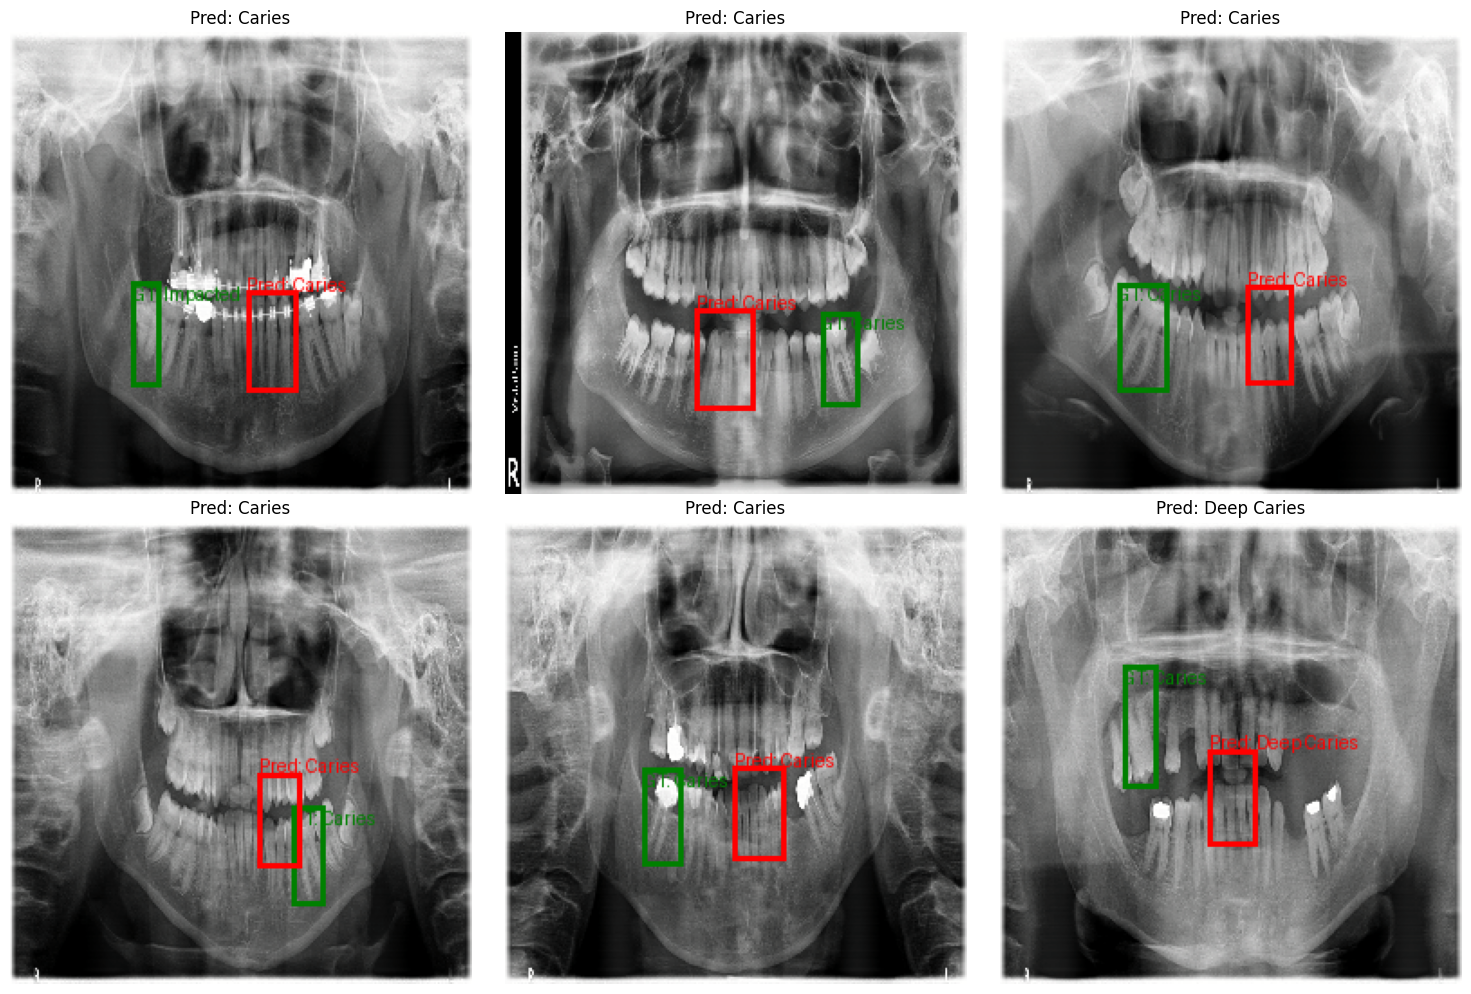

In [23]:
import torchvision.transforms.functional as TF
from PIL import ImageDraw
import matplotlib.pyplot as plt
import torch
import random
import torchvision.transforms as transforms

# ID2CLS mapping (ensure this matches your class order)
ID2CLS = ["Impacted", "Caries", "Periapical", "Deep Caries"]

def show_results(model, dataset, num_samples=6):
    model.eval()
    
    # Pick random samples
    indices = random.sample(range(len(dataset)), num_samples)
    
    plt.figure(figsize=(15, 10))
    
    for i, idx in enumerate(indices):
        img, target = dataset[idx]
        
        # 1. Predict
        with torch.no_grad():
            # Add batch dimension [1, 3, 256, 256]
            pred = model(img.unsqueeze(0).to(device)).cpu()[0]
            
        # 2. Denormalize Image for plotting
        # (Reverse the normalization stats used in Albumentations)
        inv_normalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
        img_disp = inv_normalize(img)
        img_disp = torch.clamp(img_disp, 0, 1) # Clamp to valid range
        img_pil = TF.to_pil_image(img_disp).convert("RGB")
        draw = ImageDraw.Draw(img_pil)
        W, H = img_pil.size
        
        # 3. Draw Ground Truth (GREEN)
        # Check if it's a valid box (class_id >= 0)
        # We access index 4 (class_id)
        if target[4] >= 0:
            cx, cy, w, h, cls_id = target.tolist()
            
            x1 = (cx - w/2) * W
            y1 = (cy - h/2) * H
            x2 = (cx + w/2) * W
            y2 = (cy + h/2) * H
            
            draw.rectangle([x1, y1, x2, y2], outline="green", width=3)
            draw.text((x1, y1), f"GT: {ID2CLS[int(cls_id)]}", fill="green")
        else:
            # It's an empty image (Mosaic might have cropped out all boxes)
            draw.text((10, 10), "GT: Empty", fill="green")

        # 4. Draw Prediction (RED)
        pcx, pcy, pw, ph = pred[:4].tolist()
        pcls = pred[4:].argmax().item()
        
        px1 = (pcx - pw/2) * W
        py1 = (pcy - ph/2) * H
        px2 = (pcx + pw/2) * W
        py2 = (pcy + ph/2) * H
        
        draw.rectangle([px1, py1, px2, py2], outline="red", width=3)
        draw.text((px1, py1-10), f"Pred: {ID2CLS[pcls]}", fill="red")
        
        plt.subplot(2, 3, i+1)
        plt.imshow(img_pil)
        plt.axis("off")
        plt.title(f"Pred: {ID2CLS[pcls]}")

    plt.tight_layout()
    plt.show()

# Run Visualization
show_results(model, val_set)

In [5]:
import torch
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

DATA_ROOT = "/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all"

TRAIN_IMAGES = os.path.join(DATA_ROOT, "images/train2017")
TRAIN_LABELS = os.path.join(DATA_ROOT, "labels/train2017")

VAL_IMAGES = os.path.join(DATA_ROOT, "images/val2017")
VAL_LABELS = os.path.join(DATA_ROOT, "labels/val2017")

# ============================================================
# 1. UPDATED DATASET (Handles Multiple Boxes)
# ============================================================
class DentexYOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=256, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.transform = transform

        # Get all images
        self.all_imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
        
        # Filter: Only keep images that have a corresponding label file
        # (We keep empty label files if they exist, treating them as background images)
        self.valid_imgs = []
        for img in self.all_imgs:
            lbl = img.replace(".png", ".txt")
            if os.path.exists(os.path.join(label_dir, lbl)):
                self.valid_imgs.append(img)
                
        print(f"Dataset initialized: {len(self.valid_imgs)} images found in {img_dir}")

    def __len__(self):
        return len(self.valid_imgs)

    def __getitem__(self, idx):
        img_name = self.valid_imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lbl_path = os.path.join(self.label_dir, img_name.replace(".png", ".txt"))

        # --- 1. Load Image ---
        img = Image.open(img_path).convert("RGB")
        w_orig, h_orig = img.size
        
        # Resize image
        img = img.resize((self.img_size, self.img_size))
        
        # Convert to Tensor
        if self.transform:
            img = self.transform(img)
        else:
            img = T.ToTensor()(img)

        # --- 2. Load Labels (Multiple Boxes) ---
        boxes = []
        if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
            with open(lbl_path, "r") as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    # YOLO format in file: class_id, cx, cy, w, h (normalized)
                    cls_id, cx, cy, w, h = map(float, parts)
                    
                    # We store: [class_id, cx, cy, w, h]
                    boxes.append([cls_id, cx, cy, w, h])

        # Convert to tensor. Shape: (num_boxes, 5)
        # If no boxes (background image), creates an empty tensor of shape (0, 5)
        target = torch.tensor(boxes, dtype=torch.float32)

        return img, target

# ============================================================
# 2. CUSTOM COLLATE FUNCTION
# ============================================================
def yolo_collate_fn(batch):
    """
    Custom collate function to handle variable number of bounding boxes.
    
    Args:
        batch: List of tuples (image, target) from __getitem__
    
    Returns:
        images: Tensor of shape (batch_size, 3, img_size, img_size)
        targets: Tensor of shape (total_boxes_in_batch, 6)
                 Format: [image_index, class_id, cx, cy, w, h]
    """
    images = []
    targets = []

    for i, (img, box_list) in enumerate(batch):
        images.append(img)
        
        # If the image has labels
        if box_list.size(0) > 0:
            # Create a column for the batch index (i)
            # box_list is (N, 5) -> [class, cx, cy, w, h]
            # We want (N, 6) -> [batch_idx, class, cx, cy, w, h]
            
            image_idx = torch.full((box_list.size(0), 1), i)
            labeled_boxes = torch.cat((image_idx, box_list), dim=1)
            targets.append(labeled_boxes)

    # Stack images: (Batch, C, H, W)
    images = torch.stack(images, 0)
    
    # Concatenate targets: (Total_Boxes, 6)
    if targets:
        targets = torch.cat(targets, 0)
    else:
        # Handle case where a batch has ZERO boxes (all empty images)
        targets = torch.zeros((0, 6))

    return images, targets

# ============================================================
# 3. TEST THE LOADER
# ============================================================
# Paths (Reuse your paths from previous cells)
train_dataset = DentexYOLODataset(TRAIN_IMAGES, TRAIN_LABELS, img_size=256)

# Initialize DataLoader with the new collate_fn
train_loader = DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=yolo_collate_fn, # <--- Crucial Step
    drop_last=False
)

# Verify Output
images, targets = next(iter(train_loader))

print("\n--- Batch Verification ---")
print(f"Image Batch Shape: {images.shape}  (Batch, C, H, W)")
print(f"Target Batch Shape: {targets.shape} (Total Boxes, 6)")

if len(targets) > 0:
    print("\nSample Target Row [batch_idx, class, cx, cy, w, h]:")
    print(targets[0])
    
    # Check how many boxes belong to the first image (index 0)
    num_boxes_img0 = (targets[:, 0] == 0).sum().item()
    print(f"\nImage 0 in this batch has {num_boxes_img0} diseases labeled.")

Dataset initialized: 705 images found in /Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all/images/train2017

--- Batch Verification ---
Image Batch Shape: torch.Size([8, 3, 256, 256])  (Batch, C, H, W)
Target Batch Shape: torch.Size([37, 6]) (Total Boxes, 6)

Sample Target Row [batch_idx, class, cx, cy, w, h]:
tensor([0.0000, 1.0000, 0.5594, 0.4370, 0.0344, 0.2306])

Image 0 in this batch has 3 diseases labeled.


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
import os

# ==========================================
# 1. SETUP PATHS
# ==========================================
# Ensure these match your folder structure
VAL_IMGS = os.path.join(DATA_ROOT, "images/val2017")
VAL_LBLS = os.path.join(DATA_ROOT, "labels/val2017")

print(f"Validation Images: {VAL_IMGS}")
print(f"Validation Labels: {VAL_LBLS}")

# ==========================================
# 2. DEFINE VALIDATION TRANSFORMS
# ==========================================
# Standard Validation Transform (256x256)
# NOTE: No Flips, No Noise. Just Resize & Normalize.
val_transform_standard = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# High-Res Validation Transform (512x512)
# Required for the "High Resolution" experiment to work
val_transform_highres = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# ==========================================
# 3. CREATE DATASETS
# ==========================================
# Standard Validation Set (For Baseline, Smart Aug, and Balanced experiments)
ds_val_standard = DentexDataset(
    img_dir=VAL_IMGS, 
    label_dir=VAL_LBLS, 
    img_size=256, 
    transforms=val_transform_standard
)

# High-Res Validation Set (For High-Res experiment ONLY)
ds_val_highres = DentexDataset(
    img_dir=VAL_IMGS, 
    label_dir=VAL_LBLS, 
    img_size=512, 
    transforms=val_transform_highres
)

print(f"Loaded {len(ds_val_standard)} validation images.")

# ==========================================
# 4. CREATE LOADERS (With drop_last=True)
# ==========================================
# Loader for Standard Experiments
val_loader_standard = DataLoader(
    ds_val_standard, 
    batch_size=8,        # Batch size can be small for val
    shuffle=False,       # Never shuffle validation data
    collate_fn=collate_fn, 
    drop_last=True       # Prevent BatchNorm crash
)

# Loader for High-Res Experiment
val_loader_highres = DataLoader(
    ds_val_highres, 
    batch_size=8, 
    shuffle=False, 
    collate_fn=collate_fn, 
    drop_last=True
)

print("✅ Validation Loaders Ready.")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict

# --- CONFIG ---
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
DATA_ROOT = "/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all"
TRAIN_IMGS = os.path.join(DATA_ROOT, "images/train2017")
TRAIN_LBLS = os.path.join(DATA_ROOT, "labels/train2017")
print(f"Running on: {DEVICE}")

# --- REUSABLE DATASET CLASS (Albumentations Ready) ---
class DentexDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=256, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.transforms = transforms
        
        self.valid_imgs = []
        all_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
        for img in all_files:
            lbl = img.replace(".png", ".txt")
            if os.path.exists(os.path.join(label_dir, lbl)):
                self.valid_imgs.append(img)

    def __len__(self):
        return len(self.valid_imgs)

    def __getitem__(self, idx):
        img_name = self.valid_imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lbl_path = os.path.join(self.label_dir, img_name.replace(".png", ".txt"))

        # Load Image (OpenCV is better for Albumentations)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Load Labels
        bboxes = []
        labels = []
        if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
            with open(lbl_path, 'r') as f:
                for line in f:
                    c, cx, cy, w, h = map(float, line.split())
                    bboxes.append([cx, cy, w, h])
                    labels.append(int(c))
        
        # Apply Albumentations
        if self.transforms:
            # Albumentations expects boxes in format specified in config (we use 'yolo')
            transformed = self.transforms(image=img, bboxes=bboxes, class_labels=labels)
            img = transformed['image']
            bboxes = transformed['bboxes']
            labels = transformed['class_labels']
        else:
            # Fallback (Just Resize)
            resize = A.Compose([
                A.Resize(self.img_size, self.img_size),
                A.Normalize(mean=(0.5,), std=(0.5,)),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))
            
            t = resize(image=img, bboxes=bboxes, class_labels=labels)
            img = t['image']
            bboxes = t['bboxes']
            labels = t['class_labels']

        # Convert back to Tensor format expected by Collate
        # Target format: [class_id, cx, cy, w, h]
        targets = []
        for box, label in zip(bboxes, labels):
            targets.append([label, *box])
            
        return img, torch.tensor(targets, dtype=torch.float32)

# --- COLLATE FUNCTION ---
def collate_fn(batch):
    images = []
    targets = []
    for i, (img, box_list) in enumerate(batch):
        images.append(img)
        if box_list.shape[0] > 0:
            # Add batch index: [batch_idx, class, cx, cy, w, h]
            batch_idx = torch.full((box_list.shape[0], 1), i)
            targets.append(torch.cat((batch_idx, box_list), dim=1))
    
    images = torch.stack(images, 0)
    targets = torch.cat(targets, 0) if targets else torch.zeros((0, 6))
    return images, targets

# --- CONVERTER FOR TORCHVISION ---
def convert_to_coco(images, targets, device):
    batch_size, _, h, w = images.shape
    target_list = []
    for i in range(batch_size):
        mask = (targets[:, 0] == i)
        boxes_i = targets[mask]
        
        if len(boxes_i) == 0:
            target_list.append({"boxes": torch.zeros((0, 4), device=device), "labels": torch.zeros((0,), dtype=torch.int64, device=device)})
            continue
            
        cls = boxes_i[:, 1].long() + 1 # 0->1 Mapping
        cx, cy, bw, bh = boxes_i[:, 2], boxes_i[:, 3], boxes_i[:, 4], boxes_i[:, 5]
        
        # Normalized cxcywh -> Absolute xyxy
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        x2 = (cx + bw/2) * w
        y2 = (cy + bh/2) * h
        
        boxes_xyxy = torch.stack((x1, y1, x2, y2), dim=1).clamp(0, max=max(h,w))
        target_list.append({"boxes": boxes_xyxy.to(device), "labels": cls.to(device)})
    return list(images.unbind(0)), target_list

# --- MASTER TRAINING FUNCTION ---
def train_experiment(name, train_loader, val_loader, num_epochs=10):
    print(f"\n🚀 STARTING EXPERIMENT: {name}")
    model = ssdlite320_mobilenet_v3_large(num_classes=5, pretrained_backbone=True).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    # Move metric to CPU to avoid MPS errors
    metric = MeanAveragePrecision(class_metrics=False).to("cpu") 
    
    history = {'loss': [], 'map': []}
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        # --- TRAINING ---
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            inputs, coco_targets = convert_to_coco(imgs, targets, DEVICE)
            
            loss_dict = model(inputs, coco_targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            total_loss += losses.item()
            
        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)
        
        # --- VALIDATION (Fixed: Uses val_loader) ---
        model.eval()
        metric.reset()
        with torch.no_grad():
            for imgs, targets in val_loader:
                imgs = imgs.to(DEVICE), targets.to(DEVICE)
                inputs, coco_targets = convert_to_coco(imgs, targets, DEVICE)
                
                preds = model(inputs)
                
                # Move to CPU for metrics
                preds_cpu = [{k: v.to("cpu") for k, v in p.items()} for p in preds]
                targets_cpu = [{k: v.to("cpu") for k, v in t.items()} for t in coco_targets]
                
                metric.update(preds_cpu, targets_cpu)
                
        m_res = metric.compute()
        map_score = m_res['map'].item()
        history['map'].append(map_score)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Val mAP: {map_score:.4f}")
        
    return model, history  # <--- Return model to use it later!

Running on: mps


In [ ]:
import time
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# ============================================================
# 1. SETUP MODEL
# ============================================================
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")

# num_classes = 4 diseases + 1 background = 5
model = ssdlite320_mobilenet_v3_large(num_classes=5, pretrained_backbone=True)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0005)

# Metrics: Keep on CPU to avoid MPS synchronization errors
metric = MeanAveragePrecision(class_metrics=True).to("cpu") 

# ============================================================
# 2. ROBUST FORMAT CONVERTER (FIXED)
# ============================================================
def convert_batch_to_torchvision(images, targets, device):
    """
    Converts YOLO to Torchvision, filtering out invalid/degenerate boxes.
    """
    batch_size = images.shape[0]
    height, width = images.shape[-2:]
    
    target_list = []
    
    for i in range(batch_size):
        # Cast to long to avoid float comparison errors
        batch_indices = targets[:, 0].long()
        mask = (batch_indices == i)
        boxes_i = targets[mask]
        
        valid_boxes = []
        valid_labels = []

        if len(boxes_i) > 0:
            cls = boxes_i[:, 1].long()
            labels = cls + 1  # Shift 0..3 -> 1..4
            
            cx, cy, w, h = boxes_i[:, 2], boxes_i[:, 3], boxes_i[:, 4], boxes_i[:, 5]
            
            # Denormalize
            x1 = (cx - w/2) * width
            y1 = (cy - h/2) * height
            x2 = (cx + w/2) * width
            y2 = (cy + h/2) * height
            
            # Clamp to image boundaries
            x1 = x1.clamp(min=0, max=width)
            y1 = y1.clamp(min=0, max=height)
            x2 = x2.clamp(min=0, max=width)
            y2 = y2.clamp(min=0, max=height)
            
            # --- CRITICAL FIX: Filter degenerate boxes ---
            # Remove boxes with 0 area (which cause NaN loss)
            keep = (x2 > x1 + 1.0) & (y2 > y1 + 1.0)
            
            if keep.sum() > 0:
                valid_boxes = torch.stack((x1[keep], y1[keep], x2[keep], y2[keep]), dim=1)
                valid_labels = labels[keep]

        # Handle Empty Images
        if len(valid_boxes) > 0:
            target_list.append({
                "boxes": valid_boxes.to(device),
                "labels": valid_labels.to(device)
            })
        else:
            # Explicit background target
            target_list.append({
                "boxes": torch.zeros((0, 4), dtype=torch.float32, device=device),
                "labels": torch.zeros((0,), dtype=torch.int64, device=device)
            })
            
    return list(images.unbind(0)), target_list

# ============================================================
# 3. DATALOADER (FIXED)
# ============================================================
train_dataset = DentexYOLODataset(TRAIN_IMAGES, TRAIN_LABELS, img_size=256)

train_loader = DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=yolo_collate_fn, 
    drop_last=True  # <--- MUST BE TRUE TO FIX BATCH NORM ERROR
)

# ============================================================
# 4. TRAINING LOOP
# ============================================================
NUM_EPOCHS = 10
log_interval = 10
train_losses = []
map_scores = []


    
    # ==========================
    # VALIDATION
    # ==========================
    model.eval()
    metric.reset()
    
    # Use CPU for metrics to prevent MPS errors
    print(f"Evaluating Epoch {epoch+1}...")
    with torch.no_grad():
        for imgs, raw_targets in train_loader: 
            # Note: In real report, use val_loader here!
            imgs = imgs.to(device)
            raw_targets = raw_targets.to(device)
            
            input_imgs, target_list = convert_batch_to_torchvision(imgs, raw_targets, device)
            
            # Predict
            preds = model(input_imgs)
            
            # Move to CPU for metric calculation
            preds_cpu = [{k: v.to("cpu") for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v.to("cpu") for k, v in t.items()} for t in target_list]
            
            metric.update(preds_cpu, targets_cpu)
            
    results = metric.compute()
    map_scores.append(results['map'].item())
    
    print(f"Epoch {epoch+1} Results:")
    print(f"  Train Loss: {avg_loss:.4f}")
    print(f"  mAP:        {results['map']:.4f}")
    print("-" * 30)

# ============================================================
# 5. VISUALIZATION
# ============================================================
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(train_losses, color=color, marker='o', label="Train Loss")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() 
color = 'tab:blue'
ax2.set_ylabel('mAP', color=color)
ax2.plot(map_scores, color=color, marker='s', label="Validation mAP")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Training Baseline")
fig.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import torchvision.ops as ops
from sklearn.metrics import confusion_matrix

# Classes (0 is background in our mapping logic below)
CLASSES = ["Background", "Impacted", "Caries", "Periapical", "Deep Caries"]

def get_confusion_matrix_data(model, loader, device, iou_threshold=0.5):
    """
    Matches predictions to ground truth to build confusion matrix data.
    """
    model.eval()
    y_true = []
    y_pred = []
    
    print("Generating Confusion Matrix data...")
    with torch.no_grad():
        for imgs, raw_targets in loader:
            imgs = imgs.to(device)
            raw_targets = raw_targets.to(device)
            input_imgs, target_list = convert_batch_to_torchvision(imgs, raw_targets, device)
            
            # Get Predictions
            detections = model(input_imgs)
            
            for i in range(len(input_imgs)):
                gt_boxes = target_list[i]['boxes']
                gt_labels = target_list[i]['labels'] # 1-based (1..4)
                
                pred_boxes = detections[i]['boxes']
                pred_labels = detections[i]['labels'] # 1-based (1..4)
                pred_scores = detections[i]['scores']
                
                # Filter low confidence predictions
                keep = pred_scores > 0.3
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]
                
                # --- MATCHING LOGIC ---
                if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                    continue # True Negative (Empty image correctly predicted empty)
                    
                if len(gt_boxes) == 0 and len(pred_boxes) > 0:
                    # False Positives (Background detected as Disease)
                    for l in pred_labels:
                        y_true.append(0) # Background
                        y_pred.append(l.item())
                    continue
                    
                if len(pred_boxes) == 0 and len(gt_boxes) > 0:
                    # False Negatives (Disease missed completely)
                    for l in gt_labels:
                        y_true.append(l.item())
                        y_pred.append(0) # Background
                    continue
                
                # Calculate IoU matrix between all GT and all Preds
                iou_matrix = ops.box_iou(gt_boxes, pred_boxes)
                
                # For each GT, find best matching Prediction
                for gt_idx in range(len(gt_boxes)):
                    actual_class = gt_labels[gt_idx].item()
                    
                    # Find max IoU for this Ground Truth
                    max_iou, max_idx = iou_matrix[gt_idx].max(dim=0)
                    
                    if max_iou > iou_threshold:
                        # We found a match! What class did the model predict?
                        predicted_class = pred_labels[max_idx].item()
                        y_true.append(actual_class)
                        y_pred.append(predicted_class)
                    else:
                        # No overlap found -> Missed Detection (False Negative)
                        y_true.append(actual_class)
                        y_pred.append(0) # Background

    return y_true, y_pred

# 1. Run Generation
y_true, y_pred = get_confusion_matrix_data(model, val_loader, device)

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (IoU > 0.5)")
plt.ylabel("Actual Label (Ground Truth)")
plt.xlabel("Predicted Label")
plt.show()

# 3. Visualizing Sample Predictions
def show_inference(idx=0):
    model.eval()
    img, target = val_dataset[idx]
    
    # Prepare
    img_tensor = img.unsqueeze(0).to(device)
    target_tensor = target.unsqueeze(0).to(device) # Fake batch
    input_imgs, _ = convert_batch_to_torchvision(img_tensor, target_tensor, device)
    
    with torch.no_grad():
        prediction = model(input_imgs)[0]
    
    # Draw
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5 + 0.5) # Denormalize
    plt.figure(figsize=(8, 8))
    plt.imshow(img_np)
    
    # Draw Ground Truth (Green)
    h, w, _ = img_np.shape
    for box, lbl in zip(target[:, 1:], target[:, 0]):
        cx, cy, bw, bh = box
        x1, y1 = int((cx - bw/2)*w), int((cy - bh/2)*h)
        x2, y2 = int((cx + bw/2)*w), int((cy + bh/2)*h)
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                          edgecolor='green', fill=False, linewidth=2))
        plt.text(x1, y1, f"GT: {CLASSES[int(lbl)+1]}", color='green', fontsize=8, backgroundcolor='white')

    # Draw Predictions (Red)
    keep = prediction['scores'] > 0.3
    for box, lbl, score in zip(prediction['boxes'][keep], prediction['labels'][keep], prediction['scores'][keep]):
        x1, y1, x2, y2 = box.cpu().numpy()
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                          edgecolor='red', fill=False, linewidth=2))
        plt.text(x1, y2, f"{CLASSES[int(lbl)]} {score:.2f}", color='red', fontsize=8, backgroundcolor='white')
    
    plt.axis('off')
    plt.title(f"Validation Sample {idx}")
    plt.show()

# Show a few random samples
import random
random_indices = random.sample(range(len(val_dataset)), 3)
for i in random_indices:
    show_inference(i)

In [ ]:
# --- EXPERIMENT 1: SMART AUGMENTATION ---

# Define the "Smart" Pipeline
aug_transform = A.Compose([
    # CLAHE: Critical for X-rays to see bone structure
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
    
    # Geometric
    A.HorizontalFlip(p=0.5), # Teeth can be flipped left/right
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=10, p=0.5),
    
    # Noise (Simulate sensor grain)
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    
    # Required Format
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Load Data
ds_aug = DentexDataset(TRAIN_IMGS, TRAIN_LBLS, img_size=256, transforms=aug_transform)
loader_aug = DataLoader(ds_aug, batch_size=16, shuffle=True, collate_fn=collate_fn, drop_last=True)

# Run
hist_aug = train_experiment("Smart Augmentation (CLAHE+Flip)", loader_aug, num_epochs=10)

/var/folders/qg/gflj6rgd0wj20kdyzmh7j73r0000gn/T/ipykernel_26456/3630894067.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),



🚀 STARTING EXPERIMENT: Smart Augmentation (CLAHE+Flip)


/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/.venv/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch 1/10 | Loss: 7.0299 | mAP: 0.0003
Epoch 2/10 | Loss: 4.7033 | mAP: 0.0003
Epoch 3/10 | Loss: 4.3634 | mAP: 0.0044
Epoch 4/10 | Loss: 4.1969 | mAP: 0.0210
Epoch 5/10 | Loss: 4.1140 | mAP: 0.0605
Epoch 6/10 | Loss: 4.0978 | mAP: 0.0663
Epoch 7/10 | Loss: 4.0042 | mAP: 0.0609
Epoch 8/10 | Loss: 3.9799 | mAP: 0.0756


In [ ]:
# --- EXPERIMENT 2: CLASS IMBALANCE (SAMPLING) ---

# 1. Standard Transform (No Augmentation, just Resize) to isolate the variable
base_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

ds_bal = DentexDataset(TRAIN_IMGS, TRAIN_LBLS, img_size=256, transforms=base_transform)

# 2. Calculate Weights per Image
# Heuristic: If image has rare class (Periapical/Deep Caries), give high weight.
print("Computing Sampler Weights...")
sample_weights = []
# Classes: 0:Impacted, 1:Caries, 2:Periapical, 3:Deep Caries
class_priority = {2: 10.0, 3: 5.0, 0: 2.0, 1: 1.0} 

for img_name in ds_bal.valid_imgs:
    lbl_path = os.path.join(TRAIN_LBLS, img_name.replace(".png", ".txt"))
    weight = 1.0
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                cid = int(float(line.split()[0]))
                # Assign the weight of the rarest class found in the image
                weight = max(weight, class_priority.get(cid, 1.0))
    sample_weights.append(weight)

# 3. Create Sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# 4. Loader with Sampler (shuffle must be False when using sampler)
loader_bal = DataLoader(ds_bal, batch_size=16, sampler=sampler, collate_fn=collate_fn, drop_last=True)

# Run
hist_bal = train_experiment("Balanced Sampling", loader_bal, num_epochs=10)

In [ ]:
# --- EXPERIMENT 3: HIGH RESOLUTION ---

IMG_SIZE_HIGH = 512

# High Res Transform
high_res_transform = A.Compose([
    A.Resize(IMG_SIZE_HIGH, IMG_SIZE_HIGH), # The only change
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

ds_res = DentexDataset(TRAIN_IMGS, TRAIN_LBLS, img_size=IMG_SIZE_HIGH, transforms=high_res_transform)
loader_res = DataLoader(ds_res, batch_size=8, shuffle=True, collate_fn=collate_fn, drop_last=True) 
# Note: Reduced batch size (16 -> 8) because images are 4x larger

# Run
hist_res = train_experiment(f"High Resolution ({IMG_SIZE_HIGH}px)", loader_res, num_epochs=10)

Scanning 706 label files...


/var/folders/qg/gflj6rgd0wj20kdyzmh7j73r0000gn/T/ipykernel_26456/445617915.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=values, palette="viridis")


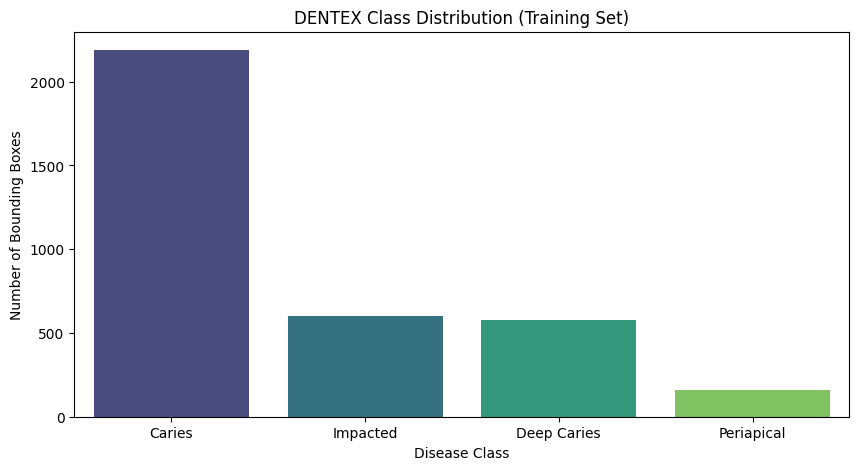


Computed Class Weights (for Loss function):
Caries: 0.4030
Impacted: 1.4607
Deep Caries: 1.5264
Periapical: 5.5839


In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ============================================================
# CONFIGURATION
# ============================================================
# Ensure these match your paths from Week 1
DATA_ROOT = "/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all"
TRAIN_LABELS = os.path.join(DATA_ROOT, "labels/train2017")

# Class mapping (Update this if your ordering is different)
ID2CLS = {0: "Impacted", 1: "Caries", 2: "Periapical", 3: "Deep Caries"}

# ============================================================
# 1. COUNT CLASSES
# ============================================================
def analyze_class_balance(label_dir):
    class_counts = Counter()
    
    label_files = glob.glob(os.path.join(label_dir, "*.txt"))
    print(f"Scanning {len(label_files)} label files...")

    for label_file in label_files:
        # Skip empty files
        if os.path.getsize(label_file) == 0:
            continue
            
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(float(parts[0]))
                class_counts[class_id] += 1
                
    return class_counts

# Run Analysis
counts = analyze_class_balance(TRAIN_LABELS)

# ============================================================
# 2. VISUALIZE
# ============================================================
classes = [ID2CLS.get(k, f"Class {k}") for k in counts.keys()]
values = list(counts.values())

plt.figure(figsize=(10, 5))
sns.barplot(x=classes, y=values, palette="viridis")
plt.title("DENTEX Class Distribution (Training Set)")
plt.xlabel("Disease Class")
plt.ylabel("Number of Bounding Boxes")
plt.show()

# Calculate Weights (Inverse Frequency)
total_samples = sum(values)
class_weights = {k: total_samples / (len(counts) * v) for k, v in counts.items()}

print("\nComputed Class Weights (for Loss function):")
for cid, weight in class_weights.items():
    print(f"{ID2CLS.get(cid)}: {weight:.4f}")

In [ ]:
#A wokring code, but soon to be improved

Training on: mps
Dataset initialized: 705 images found in /Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all/images/train2017
Starting training...
Epoch 1 [0/88] Loss: 18.5202
Epoch 1 [10/88] Loss: 9.0062
Epoch 1 [20/88] Loss: 6.7559
Epoch 1 [30/88] Loss: 6.2513
Epoch 1 [40/88] Loss: 4.7720
Epoch 1 [50/88] Loss: 5.1250
Epoch 1 [60/88] Loss: 5.2050
Epoch 1 [70/88] Loss: 4.6467
Epoch 1 [80/88] Loss: 4.1396
Evaluating Epoch 1...


/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/.venv/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch 1 Results:
  Train Loss: 6.3293
  mAP:        0.0002
------------------------------
Epoch 2 [0/88] Loss: 3.9228
Epoch 2 [10/88] Loss: 4.1425
Epoch 2 [20/88] Loss: 4.0137
Epoch 2 [30/88] Loss: 4.1049
Epoch 2 [40/88] Loss: 4.4947
Epoch 2 [50/88] Loss: 4.2368
Epoch 2 [60/88] Loss: 4.6537
Epoch 2 [70/88] Loss: 4.0760
Epoch 2 [80/88] Loss: 4.3931
Evaluating Epoch 2...
Epoch 2 Results:
  Train Loss: 4.2930
  mAP:        0.0096
------------------------------
Epoch 3 [0/88] Loss: 3.8392
Epoch 3 [10/88] Loss: 3.8788
Epoch 3 [20/88] Loss: 3.5341
Epoch 3 [30/88] Loss: 3.9083
Epoch 3 [40/88] Loss: 3.9288
Epoch 3 [50/88] Loss: 4.0334
Epoch 3 [60/88] Loss: 3.5091
Epoch 3 [70/88] Loss: 3.6531
Epoch 3 [80/88] Loss: 3.6572
Evaluating Epoch 3...
Epoch 3 Results:
  Train Loss: 3.8896
  mAP:        0.0767
------------------------------
Epoch 4 [0/88] Loss: 3.3604
Epoch 4 [10/88] Loss: 3.4279
Epoch 4 [20/88] Loss: 3.3956
Epoch 4 [30/88] Loss: 3.2856
Epoch 4 [40/88] Loss: 3.7372
Epoch 4 [50/88] Loss: 

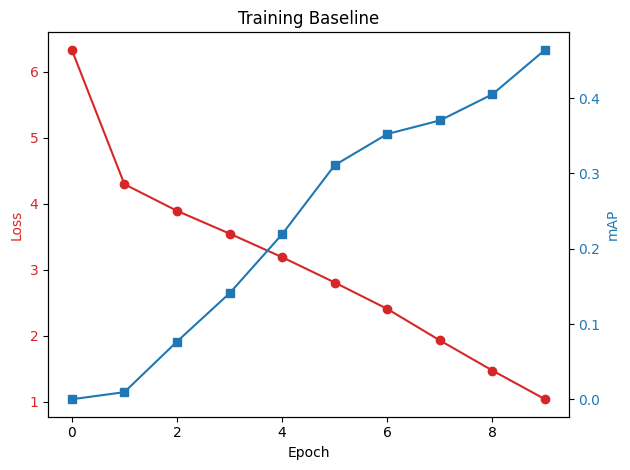

In [10]:
import time
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# ============================================================
# 1. SETUP MODEL
# ============================================================
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")

# num_classes = 4 diseases + 1 background = 5
model = ssdlite320_mobilenet_v3_large(num_classes=5, pretrained_backbone=True)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0005)

# Metrics: Keep on CPU to avoid MPS synchronization errors
metric = MeanAveragePrecision(class_metrics=True).to("cpu") 

# ============================================================
# 2. ROBUST FORMAT CONVERTER (FIXED)
# ============================================================
def convert_batch_to_torchvision(images, targets, device):
    """
    Converts YOLO to Torchvision, filtering out invalid/degenerate boxes.
    """
    batch_size = images.shape[0]
    height, width = images.shape[-2:]
    
    target_list = []
    
    for i in range(batch_size):
        # Cast to long to avoid float comparison errors
        batch_indices = targets[:, 0].long()
        mask = (batch_indices == i)
        boxes_i = targets[mask]
        
        valid_boxes = []
        valid_labels = []

        if len(boxes_i) > 0:
            cls = boxes_i[:, 1].long()
            labels = cls + 1  # Shift 0..3 -> 1..4
            
            cx, cy, w, h = boxes_i[:, 2], boxes_i[:, 3], boxes_i[:, 4], boxes_i[:, 5]
            
            # Denormalize
            x1 = (cx - w/2) * width
            y1 = (cy - h/2) * height
            x2 = (cx + w/2) * width
            y2 = (cy + h/2) * height
            
            # Clamp to image boundaries
            x1 = x1.clamp(min=0, max=width)
            y1 = y1.clamp(min=0, max=height)
            x2 = x2.clamp(min=0, max=width)
            y2 = y2.clamp(min=0, max=height)
            
            # --- CRITICAL FIX: Filter degenerate boxes ---
            # Remove boxes with 0 area (which cause NaN loss)
            keep = (x2 > x1 + 1.0) & (y2 > y1 + 1.0)
            
            if keep.sum() > 0:
                valid_boxes = torch.stack((x1[keep], y1[keep], x2[keep], y2[keep]), dim=1)
                valid_labels = labels[keep]

        # Handle Empty Images
        if len(valid_boxes) > 0:
            target_list.append({
                "boxes": valid_boxes.to(device),
                "labels": valid_labels.to(device)
            })
        else:
            # Explicit background target
            target_list.append({
                "boxes": torch.zeros((0, 4), dtype=torch.float32, device=device),
                "labels": torch.zeros((0,), dtype=torch.int64, device=device)
            })
            
    return list(images.unbind(0)), target_list

# ============================================================
# 3. DATALOADER (FIXED)
# ============================================================
train_dataset = DentexYOLODataset(TRAIN_IMAGES, TRAIN_LABELS, img_size=256)

train_loader = DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=yolo_collate_fn, 
    drop_last=True  # <--- MUST BE TRUE TO FIX BATCH NORM ERROR
)

# ============================================================
# 4. TRAINING LOOP
# ============================================================
NUM_EPOCHS = 10
log_interval = 10
train_losses = []
map_scores = []

print("Starting training...")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    
    for batch_idx, (imgs, raw_targets) in enumerate(train_loader):
        imgs = imgs.to(device)
        raw_targets = raw_targets.to(device)
        
        # Convert Data format
        input_imgs, target_list = convert_batch_to_torchvision(imgs, raw_targets, device)
        
        # Forward Pass
        loss_dict = model(input_imgs, target_list)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        
        if batch_idx % log_interval == 0:
            print(f"Epoch {epoch+1} [{batch_idx}/{len(train_loader)}] Loss: {losses.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # ==========================
    # VALIDATION
    # ==========================
    model.eval()
    metric.reset()
    
    # Use CPU for metrics to prevent MPS errors
    print(f"Evaluating Epoch {epoch+1}...")
    with torch.no_grad():
        for imgs, raw_targets in train_loader: 
            # Note: In real report, use val_loader here!
            imgs = imgs.to(device)
            raw_targets = raw_targets.to(device)
            
            input_imgs, target_list = convert_batch_to_torchvision(imgs, raw_targets, device)
            
            # Predict
            preds = model(input_imgs)
            
            # Move to CPU for metric calculation
            preds_cpu = [{k: v.to("cpu") for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v.to("cpu") for k, v in t.items()} for t in target_list]
            
            metric.update(preds_cpu, targets_cpu)
            
    results = metric.compute()
    map_scores.append(results['map'].item())
    
    print(f"Epoch {epoch+1} Results:")
    print(f"  Train Loss: {avg_loss:.4f}")
    print(f"  mAP:        {results['map']:.4f}")
    print("-" * 30)

# ============================================================
# 5. VISUALIZATION
# ============================================================
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(train_losses, color=color, marker='o', label="Train Loss")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() 
color = 'tab:blue'
ax2.set_ylabel('mAP', color=color)
ax2.plot(map_scores, color=color, marker='s', label="Validation mAP")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Training Baseline")
fig.tight_layout()
plt.show()